# LAB013–LAB015: information added by reliable offline measurements

This notebook compares a historical natural-must calibration with an augmented
global calibration that adds reliable offline observations from the nominal
triplicate LAB013–LAB015. The gas-phase CO$_2$ measurements from these three
reactors have known measurement problems and are **never used for parameter
estimation**. They are loaded only in a separated diagnostic block.

The biological parameters remain shared across all experiments. No data file,
model source file, or other notebook is written by this analysis.

## Methodological change and scenarios

- **A — historical baseline:** the saved natural-must fit from
  `estimability_historical_natural`, based on nine historical natural-must
  batches and the repository's existing scaled multistate residuals.
- **B — augmented global fit:** the identical historical residual block plus
  scientifically compatible offline LAB013–LAB015 observations.
- The natural-must gas-transfer parameters remain fixed at their prior fit.
  They are not re-estimated here.
- LAB013–LAB015 gas CO$_2$ is absent from both objective functions. No
  apparently “good” subinterval is selected.

Historical gas-phase CO$_2$ is also absent from the biological calibration
objective in the existing repository workflow (`co2_values_used_in_parameter_fit`
is false). Its recorded calibration/holdout curves are evaluated after fitting as
an independent preservation check using the existing fixed CO$_2$ observation
layer.

In [1]:
from pathlib import Path
import json
import math
import sys
import warnings
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "fermentation_model").is_dir():
            return candidate
    raise RuntimeError("Repository root containing fermentation_model was not found")

ROOT = find_repo_root(Path.cwd())
FM = ROOT / "fermentation_model"
for module_path in (FM, FM / "laboratory_2026", FM / "pilot_2025"):
    if str(module_path) not in sys.path:
        sys.path.insert(0, str(module_path))

from shared import new_must_data_loader
from shared import run_new_must_glycerol_estimability_doe as base
from laboratory_2026 import run_estimability_historical_by_medium as historical
from laboratory_2026 import run_final_operational_doe_v2 as final
from laboratory_2026 import run_co2_matrix_cross_validation_2026 as co2_layer

DATA_DIR = FM / "data" / "mem2026" / "LAB013-015"
HIST_RESULTS = FM / "laboratory_2026" / "results" / "estimability_historical_natural"
CO2_RESULTS = FM / "laboratory_2026" / "results" / "co2_matrix_cross_validation_2026"
LABS = ("LAB013", "LAB014", "LAB015")
LAB_TO_F = {"LAB013": "F1", "LAB014": "F2", "LAB015": "F3"}
REACTOR_VOLUME_L = 2.0

print("Repository root:", ROOT.name)
print("Biological state vector:", base.STATE_NAMES)
print("Shared fitted parameters:", final.FERMENTATION_TARGETS)

Repository root: pyomo-doe
Biological state vector: ('X', 'Xd', 'N', 'G', 'F', 'E', 'Gly')
Shared fitted parameters: ('mu0', 'qN', 'betaG0', 'betaF0', 'qEG', 'qEF', 'iG', 'iE', 'Kd0', 'gammaG0', 'gammaF0')


## 1. Source and schema audit

All paths below are repository-relative. The requested cleaned Y15 filename is
checked explicitly. If it is absent, the available processed CSV is used without
modifying or renaming it. `LABxxx-PI` rows are pre-inoculum measurements: they
provide must composition for initial conditions but are not dynamic sample 1 and
contribute no residual.

In [2]:
requested = {
    "offline": DATA_DIR / "LAB013-LAB015-offline-measurements.csv",
    "combined": DATA_DIR / "LAB013-LAB015-offline-combined.csv",
    "y15_clean_requested": DATA_DIR / "Y15_LAB013-015_clean.csv",
    "y15_available_fallback": DATA_DIR / "Y15_LAB013-015.csv",
    "dissolved_reference": FM / "data" / "mem2026" / "Tabla_CO2_disuelto_carbodoseur_long.csv",
    "historical_theta": HIST_RESULTS / "theta.csv",
    "historical_summary": HIST_RESULTS / "summary.json",
    "co2_layer_parameters": CO2_RESULTS / "fit_parameters.csv",
    "historical_co2": CO2_RESULTS / "co2_observations_hourly.csv",
}
source_audit = pd.DataFrame(
    [{"source": key, "relative_path": path.relative_to(ROOT).as_posix(), "exists": path.exists()}
     for key, path in requested.items()]
)
display(source_audit)
for required_key in ("offline", "combined", "y15_available_fallback", "historical_theta",
                     "historical_summary", "co2_layer_parameters", "historical_co2"):
    assert requested[required_key].exists(), requested[required_key]

Y15_PATH = (requested["y15_clean_requested"] if requested["y15_clean_requested"].exists()
            else requested["y15_available_fallback"])
if not requested["y15_clean_requested"].exists():
    print("AUDIT NOTE: Y15_LAB013-015_clean.csv is absent; using existing processed Y15_LAB013-015.csv.")

,source,relative_path,exists
0,offline,fermentation_model/data/mem2026/LAB013-015/LAB...,True
1,combined,fermentation_model/data/mem2026/LAB013-015/LAB...,True
2,y15_clean_requested,fermentation_model/data/mem2026/LAB013-015/Y15...,False
3,y15_available_fallback,fermentation_model/data/mem2026/LAB013-015/Y15...,True
4,dissolved_reference,fermentation_model/data/mem2026/Tabla_CO2_disu...,True
5,historical_theta,fermentation_model/laboratory_2026/results/est...,True
6,historical_summary,fermentation_model/laboratory_2026/results/est...,True
7,co2_layer_parameters,fermentation_model/laboratory_2026/results/co2...,True
8,historical_co2,fermentation_model/laboratory_2026/results/co2...,True


AUDIT NOTE: Y15_LAB013-015_clean.csv is absent; using existing processed Y15_LAB013-015.csv.


## 2. State–observable compatibility

The current biological implementation has separate glucose (`G`) and fructose
(`F`) states rather than a single `S`. The Y15 total is therefore observed with
the exact algebraic observation function

$$H_S(x)=G+F.$$

This avoids fitting the same Y15 assay twice through its reported components.
The repository loader explicitly defines `N_kg_m3 = YAN_mg_l × 10⁻³`, so YAN is
compatible with `N`; ammonia and PAN remain component-level validation. Glycerol
maps directly to `Gly`.

The gas-transfer layer already contains a latent dissolved-CO$_2$ pool. It is
exposed below by replaying the exact existing mass-balance update from
`raw_qgas_grid_prediction`; no state or equation is added. Measured mg/L is
converted to g/L. The initial dissolved measurement is validation-only because
the existing layer fixes the latent pool to zero at model time zero.

In [3]:
mapping = pd.DataFrame([
    {"measurement": "glucose_fructose_g_L", "model observable": "G + F", "unit conversion": "none (g/L)", "role": "fit"},
    {"measurement": "YAN_mg_L", "model observable": "N", "unit conversion": "× 1e-3 → kg/m³", "role": "fit"},
    {"measurement": "glycerol_g_L", "model observable": "Gly", "unit conversion": "none (g/L)", "role": "fit"},
    {"measurement": "CO2_dissolved_actualT_mg_L (t>0)", "model observable": "existing latent dissolved CO2 pool", "unit conversion": "× 1e-3 → g/L", "role": "fit"},
    {"measurement": "CO2_dissolved_actualT_mg_L (t=0)", "model observable": "latent pool fixed to zero initially", "unit conversion": "× 1e-3 → g/L", "role": "validation"},
    {"measurement": "ammonia_mg_L, PAN_mg_L", "model observable": "no component states", "unit conversion": "none", "role": "validation"},
    {"measurement": "Brix, density", "model observable": "no repository observation function used here", "unit conversion": "none", "role": "validation"},
    {"measurement": "dissolved O2", "model observable": "not a biological-fit state", "unit conversion": "none", "role": "validation"},
    {"measurement": "LAB013–LAB015 gas CO2", "model observable": "gas observation layer", "unit conversion": "sccm → g/L/h for display", "role": "diagnostic only; excluded"},
])
display(mapping)
assert new_must_data_loader.MG_L_TO_KG_M3 == 1e-3
assert base.STATE_COLUMNS["N"] == "N_kg_m3"
assert base.STATE_COLUMNS["Gly"] == "glycerol_g_l"

,measurement,model observable,unit conversion,role
0,glucose_fructose_g_L,G + F,none (g/L),fit
1,YAN_mg_L,N,× 1e-3 → kg/m³,fit
2,glycerol_g_L,Gly,none (g/L),fit
3,CO2_dissolved_actualT_mg_L (t>0),existing latent dissolved CO2 pool,× 1e-3 → g/L,fit
4,CO2_dissolved_actualT_mg_L (t=0),latent pool fixed to zero initially,× 1e-3 → g/L,validation
5,"ammonia_mg_L, PAN_mg_L",no component states,none,validation
6,"Brix, density",no repository observation function used here,none,validation
7,dissolved O2,not a biological-fit state,none,validation
8,LAB013–LAB015 gas CO2,gas observation layer,sccm → g/L/h for display,diagnostic only; excluded


## 3. Historical baseline

The same loader, equations, parameter bounds, state error floors, and relative
errors used by the prior natural-must analysis are reused. Scenario A is loaded
from the saved result rather than refitted or silently redefined.

In [4]:
historical_data, historical_batches, historical_co2_times, historical_tables = historical.make_medium_batches("natural")
theta_table = pd.read_csv(requested["historical_theta"])
theta_A = dict(base.DEFAULT_THETA)
theta_A.update(dict(zip(theta_table["parameter"], theta_table["theta"])))
theta_A = {name: float(value) for name, value in theta_A.items()}
CORE_PARAMETERS = tuple(final.FERMENTATION_TARGETS)
historical_summary = json.loads(requested["historical_summary"].read_text(encoding="utf-8"))

assert historical_summary["co2_values_used_in_parameter_fit"] is False
historical_batch_audit = pd.DataFrame([
    {
        "batch": batch.batch,
        "n_model_times": len(batch.time),
        "n_scaled_state_observations": sum(np.isfinite(batch.observations[s]).sum() for s in base.STATE_NAMES),
        "t_end_h": float(batch.time.max()),
    }
    for batch in historical_batches
])
display(historical_batch_audit)
print("Historical natural batches:", len(historical_batches))
print("Historical gas CO2 values used in the prior biological fit:", historical_summary["co2_values_used_in_parameter_fit"])

,batch,n_model_times,n_scaled_state_observations,t_end_h
0,LAB004,89,81,163.0
1,LAB005,89,81,163.0
2,LAB006,114,93,211.0
3,LAB007,82,84,160.0
4,LAB008,82,84,160.0
5,LAB009,82,77,160.0
6,LAB010,101,38,187.0
7,LAB011,87,34,163.0
8,LAB012,88,36,163.0


Historical natural batches: 9
Historical gas CO2 values used in the prior biological fit: False


## 4. LAB013–LAB015 synchronization and offline audit

Model time zero remains the first numbered chemical sample, consistent with the
historical workflow. Y15 timestamps are retained at their actual analysis times.
The PI records remain distinct and are never relabeled as sample 1.

In [5]:
offline = pd.read_csv(requested["offline"])
combined_source = pd.read_csv(requested["combined"])
y15 = pd.read_csv(Y15_PATH)

offline["sample_datetime"] = pd.to_datetime(
    offline["fecha_muestreo"].astype(str) + " " + offline["hora_muestreo"].astype(str), errors="coerce"
)
y15["y15_datetime"] = pd.to_datetime(y15["y15_datetime"], errors="coerce")
t0_by_lab = (
    offline[offline["sample_id"].str.endswith("-1")]
    .set_index("lab_id")["sample_datetime"].to_dict()
)
offline["time_h_model"] = [
    (stamp - t0_by_lab[lab]).total_seconds() / 3600.0
    for lab, stamp in zip(offline["lab_id"], offline["sample_datetime"])
]
y15["time_h_model"] = [
    np.nan if str(sample_type) == "pre_inoculum" else (stamp - t0_by_lab[lab]).total_seconds() / 3600.0
    for lab, stamp, sample_type in zip(y15["lab_id"], y15["y15_datetime"], y15["sample_type"])
]

numeric_offline = ["time_h_model", "brix_degBx", "rho_value", "temperature_C", "DO_value", "CO2_dissolved_actualT_mg_L"]
numeric_y15 = ["time_h_model", "YAN_mg_L", "ammonia_mg_L", "PAN_mg_L", "glucose_g_L",
               "glucose_fructose_g_L", "fructose_g_L", "glycerol_g_L"]
for column in numeric_offline:
    offline[column] = pd.to_numeric(offline[column], errors="coerce")
for column in numeric_y15:
    y15[column] = pd.to_numeric(y15[column], errors="coerce")

pi = y15[y15["sample_type"].eq("pre_inoculum")].copy()
dynamic_y15 = y15[y15["sample_type"].eq("fermentation_sample")].dropna(subset=["time_h_model"]).copy()
assert set(pi["sample_id"]) == {f"{lab}-PI" for lab in LABS}
assert not dynamic_y15["sample_id"].str.endswith("-PI").any()

coverage_rows = []
for lab in LABS:
    off = offline[offline["lab_id"].eq(lab)]
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)]
    coverage_rows.append({
        "lab_id": lab,
        "numbered_offline_samples": len(off),
        "dynamic_Y15_samples": len(dyn),
        "pre_inoculum_rows": int(pi["lab_id"].eq(lab).sum()),
        "S_points": int(dyn["glucose_fructose_g_L"].notna().sum()),
        "N_points": int(dyn["YAN_mg_L"].notna().sum()),
        "Gly_points": int(dyn["glycerol_g_L"].notna().sum()),
        "dissolved_CO2_fit_points_t_gt_0": int((off["CO2_dissolved_actualT_mg_L"].notna() & off["time_h_model"].gt(0)).sum()),
        "DO_missing": int(off["DO_value"].isna().sum()),
        "t_end_h": float(off["time_h_model"].max()),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage)
display(pi[["sample_id", "sample_type", "YAN_mg_L", "glucose_g_L", "fructose_g_L", "glycerol_g_L"]])
print("Combined source rows/columns:", combined_source.shape)

,lab_id,numbered_offline_samples,dynamic_Y15_samples,pre_inoculum_rows,S_points,N_points,Gly_points,dissolved_CO2_fit_points_t_gt_0,DO_missing,t_end_h
0,LAB013,10,7,1,7,7,7,6,2,143.5
1,LAB014,10,7,1,7,7,7,6,2,143.5
2,LAB015,10,7,1,7,7,7,6,2,143.5


,sample_id,sample_type,YAN_mg_L,glucose_g_L,fructose_g_L,glycerol_g_L
0,LAB013-PI,pre_inoculum,249.0,75.62,79.03,1.15
8,LAB014-PI,pre_inoculum,247.0,76.54,80.38,1.12
16,LAB015-PI,pre_inoculum,246.0,75.32,79.45,1.12


Combined source rows/columns: (30, 27)


## 5. Replicate trajectories and validation measurements

,lab_id,mean_YAN_mg_L,mean_ammonia_plus_PAN_mg_L,mean_component_minus_YAN_mg_L,correlation
0,LAB013,215.571429,243.000000,27.428571,0.999874
1,LAB014,214.000000,241.142857,27.142857,0.999901
2,LAB015,220.428571,248.857143,28.428571,0.999925


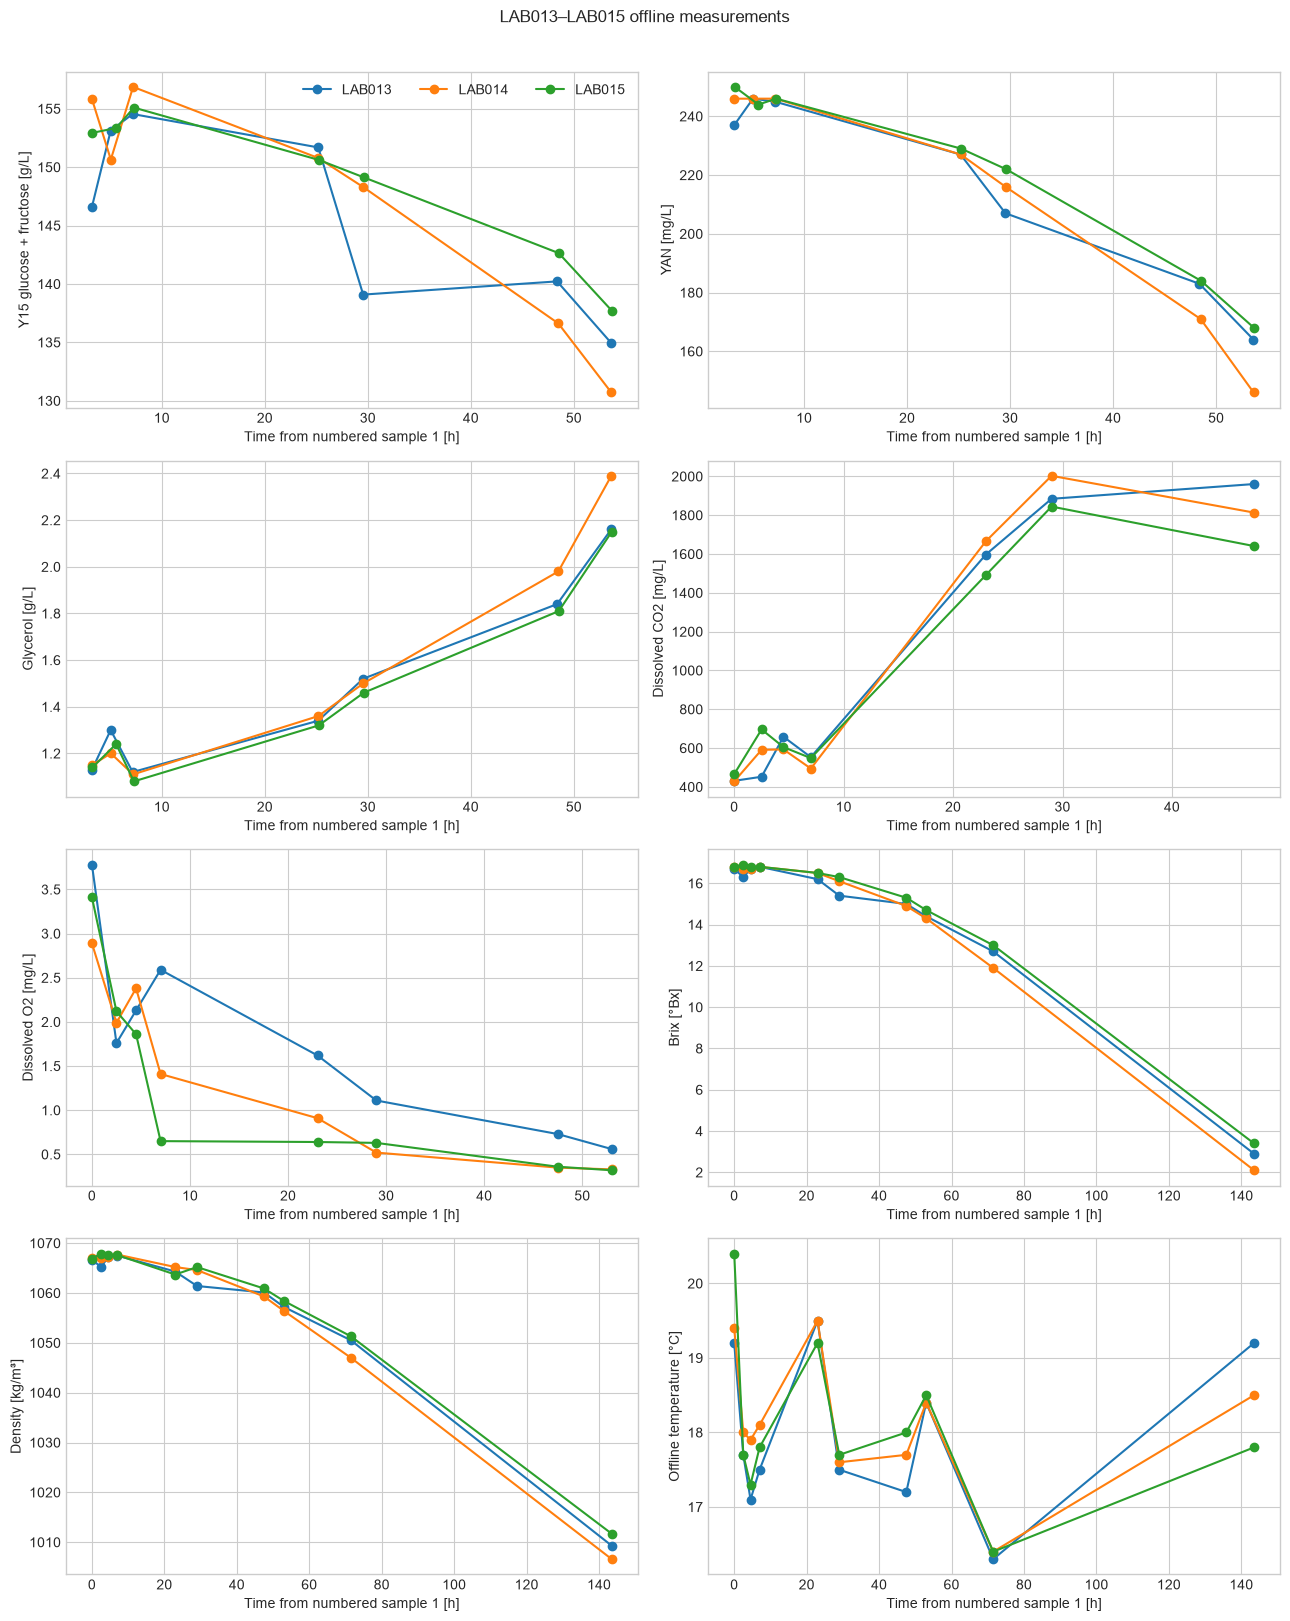

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16), sharex=False)
panels = [
    ("glucose_fructose_g_L", "Y15 glucose + fructose [g/L]", dynamic_y15, "time_h_model"),
    ("YAN_mg_L", "YAN [mg/L]", dynamic_y15, "time_h_model"),
    ("glycerol_g_L", "Glycerol [g/L]", dynamic_y15, "time_h_model"),
    ("CO2_dissolved_actualT_mg_L", "Dissolved CO2 [mg/L]", offline, "time_h_model"),
    ("DO_value", "Dissolved O2 [mg/L]", offline, "time_h_model"),
    ("brix_degBx", "Brix [°Bx]", offline, "time_h_model"),
    ("rho_value", "Density [kg/m³]", offline, "time_h_model"),
    ("temperature_C", "Offline temperature [°C]", offline, "time_h_model"),
]
for ax, (column, ylabel, frame, time_column) in zip(axes.ravel(), panels):
    for lab in LABS:
        group = frame[frame["lab_id"].eq(lab)].dropna(subset=[time_column, column])
        ax.plot(group[time_column], group[column], marker="o", label=lab)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time from numbered sample 1 [h]")
axes[0, 0].legend(ncol=3)
fig.suptitle("LAB013–LAB015 offline measurements", y=1.01)
fig.tight_layout()
plt.show()

nitrogen_check = dynamic_y15.assign(
    ammonia_plus_PAN_mg_L=dynamic_y15["ammonia_mg_L"] + dynamic_y15["PAN_mg_L"]
)
nitrogen_component_audit = nitrogen_check.groupby("lab_id").apply(
    lambda g: pd.Series({
        "mean_YAN_mg_L": g["YAN_mg_L"].mean(),
        "mean_ammonia_plus_PAN_mg_L": g["ammonia_plus_PAN_mg_L"].mean(),
        "mean_component_minus_YAN_mg_L": (g["ammonia_plus_PAN_mg_L"] - g["YAN_mg_L"]).mean(),
        "correlation": g[["YAN_mg_L", "ammonia_plus_PAN_mg_L"]].corr().iloc[0, 1],
    }), include_groups=False
).reset_index()
display(nitrogen_component_audit)

## 6. Gas-phase CO$_2$: separated diagnostic data

These signals are loaded into `gas_reference` only. That object is not accepted
by the biological residual function defined later. All panels carry the explicit
exclusion notice. Gas-linked lag estimates from the previous version are not
retained because a delay inferred from known faulty signals would not be a
defensible kinetic result.

,n_hourly,used_in_fit
lab_id,,
LAB013,143,False
LAB014,143,False
LAB015,143,False


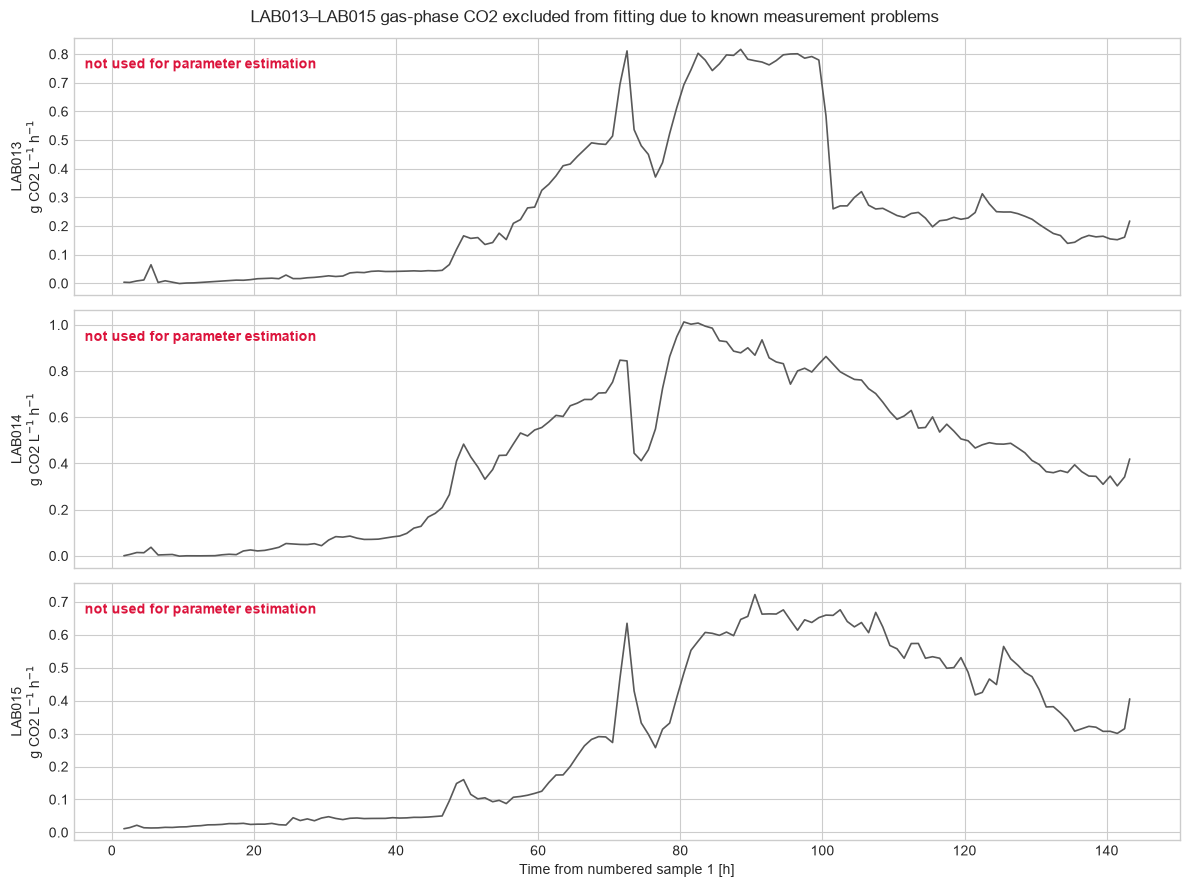

In [7]:
gas_frames = []
for lab, fermenter in LAB_TO_F.items():
    path = DATA_DIR / f"CO2_FILT_{fermenter}_{lab}.csv"
    frame = pd.read_csv(path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], errors="coerce")
    frame["flow_filt_sccm"] = pd.to_numeric(frame["flow_filt_sccm"], errors="coerce")
    frame["lab_id"] = lab
    frame["t_h"] = (frame["timestamp"] - t0_by_lab[lab]).dt.total_seconds() / 3600.0
    frame = frame[frame["t_h"].between(0.0, float(offline.loc[offline["lab_id"].eq(lab), "time_h_model"].max()))]
    frame["hour"] = np.floor(frame["t_h"]).astype(int)
    hourly = frame.groupby(["lab_id", "hour"], as_index=False).agg(
        t_h=("t_h", "median"), flow_sccm=("flow_filt_sccm", "median"), spike_fraction=("is_spike", "mean")
    )
    hourly["co2_rate_g_l_h"] = (
        hourly["flow_sccm"] * 60.0 / 1000.0 * co2_layer.CO2_MOLAR_MASS_G_MOL
        / co2_layer.STANDARD_MOLAR_VOLUME_L_MOL / REACTOR_VOLUME_L
    )
    hourly["used_in_fit"] = False
    gas_frames.append(hourly)
gas_reference = pd.concat(gas_frames, ignore_index=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, lab in zip(axes, LABS):
    group = gas_reference[gas_reference["lab_id"].eq(lab)]
    ax.plot(group["t_h"], group["co2_rate_g_l_h"], color="0.35", lw=1.2)
    ax.set_ylabel(f"{lab}\ng CO2 L$^{{-1}}$ h$^{{-1}}$")
    ax.text(0.01, 0.92, "not used for parameter estimation", transform=ax.transAxes,
            color="crimson", weight="bold", va="top")
axes[-1].set_xlabel("Time from numbered sample 1 [h]")
fig.suptitle("LAB013–LAB015 gas-phase CO2 excluded from fitting due to known measurement problems")
fig.tight_layout()
plt.show()
display(gas_reference.groupby("lab_id").agg(n_hourly=("t_h", "size"), used_in_fit=("used_in_fit", "any")))

## 7. LAB013–LAB015 model batches and initial conditions

Reactor-specific initial must composition comes from each PI row. Biomass,
dead biomass, and ethanol were not measured and use the existing natural-must
fallbacks (`X=0.45 kg/m³`, `Xd=0`, `E=0`). No nutrient pulse is present in the
temperature acquisition files. Temperatures are resampled to 30-minute medians;
the numbered sample-1 temperature anchors the interval before sensor acquisition.

In [8]:
lab_batches = {}
temperature_inputs = []
for lab, fermenter in LAB_TO_F.items():
    off = offline[offline["lab_id"].eq(lab)].sort_values("time_h_model")
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    pi_row = pi[pi["lab_id"].eq(lab)].iloc[0]
    temp = pd.read_csv(DATA_DIR / f"Temp_{fermenter}_{lab}.csv", usecols=["timestamp", "T", "nutricion_activa"])
    temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
    temp["T"] = pd.to_numeric(temp["T"], errors="coerce")
    assert pd.to_numeric(temp["nutricion_activa"], errors="coerce").fillna(0).eq(0).all()
    temp = temp.dropna(subset=["timestamp", "T"]).set_index("timestamp")["T"].resample("30min").median().dropna().reset_index()
    temp["time_h_model"] = (temp["timestamp"] - t0_by_lab[lab]).dt.total_seconds() / 3600.0
    horizon = float(off["time_h_model"].max())
    temp = temp[temp["time_h_model"].between(0.0, horizon)]
    anchor = pd.DataFrame({"timestamp": [t0_by_lab[lab]], "T": [float(off.iloc[0]["temperature_C"])], "time_h_model": [0.0]})
    temp = pd.concat([anchor, temp], ignore_index=True).sort_values("time_h_model").drop_duplicates("time_h_model")
    temperature_inputs.append(temp.assign(lab_id=lab))

    model_time = np.unique(np.concatenate([
        np.array([0.0, horizon]), off["time_h_model"].dropna().to_numpy(float),
        dyn["time_h_model"].dropna().to_numpy(float), temp["time_h_model"].to_numpy(float)
    ]))
    temperature = np.interp(model_time, temp["time_h_model"], temp["T"])
    observations = {state: np.full(len(model_time), np.nan) for state in base.STATE_NAMES}
    for _, row in dyn.iterrows():
        idx = int(np.argmin(np.abs(model_time - float(row["time_h_model"]))))
        observations["N"][idx] = float(row["YAN_mg_L"]) * 1e-3
        observations["G"][idx] = float(row["glucose_g_L"])
        observations["F"][idx] = float(row["fructose_g_L"])
        observations["Gly"][idx] = float(row["glycerol_g_L"])
    initials = {
        "X": 0.45, "Xd": 0.0,
        "N": float(pi_row["YAN_mg_L"]) * 1e-3,
        "G": float(pi_row["glucose_g_L"]), "F": float(pi_row["fructose_g_L"]),
        "E": 0.0, "Gly": float(pi_row["glycerol_g_L"]),
    }
    lab_batches[lab] = base.BatchData(
        medium="natural", batch=lab, time=model_time, temperature_c=temperature,
        pulses={channel: tuple() for channel in base.INPUT_CHANNELS},
        observations=observations, initials=initials,
    )

temperature_inputs = pd.concat(temperature_inputs, ignore_index=True)
initial_conditions = pd.DataFrame([{"lab_id": lab, **batch.initials} for lab, batch in lab_batches.items()])
display(initial_conditions)
display(temperature_inputs.groupby("lab_id")["T"].agg(["count", "min", "mean", "max"]))

,lab_id,X,Xd,N,G,F,E,Gly
0,LAB013,0.45,0.0,0.249,75.62,79.03,0.0,1.15
1,LAB014,0.45,0.0,0.247,76.54,80.38,0.0,1.12
2,LAB015,0.45,0.0,0.246,75.32,79.45,0.0,1.12


,count,min,mean,max
lab_id,,,,
LAB013,287,15.6,16.012544,19.2
LAB014,287,15.6,16.033624,19.4
LAB015,287,15.6,16.015157,20.4


## 8. Fixed CO$_2$ observation layer and dissolved-pool wrapper

The wrapper below calls the repository's `raw_qgas_grid_prediction` and reconstructs
its latent dissolved pool from the same discrete balance

$$C_{k}=\max\{C_{k-1}+\Delta t(q_{prod,k-1}-q_{gas,k}),0\}.$$

Only the shared biological parameter vector changes between scenarios. Natural-must
release, saturation, oxygen-gating, activation, and matrix-gain parameters stay at
their saved historical values. Matrix gain scales the sensor signal and therefore
is not applied to the physical dissolved pool.

In [9]:
co2_parameter_table = pd.read_csv(requested["co2_layer_parameters"])
fixed_co2_parameters = dict(zip(
    co2_parameter_table.loc[co2_parameter_table["calibration_matrix"].eq("natural"), "parameter"],
    co2_parameter_table.loc[co2_parameter_table["calibration_matrix"].eq("natural"), "estimate"],
))
display(co2_parameter_table[co2_parameter_table["calibration_matrix"].eq("natural")])

dissolved_support = pd.concat([
    offline[(offline["lab_id"].eq(lab)) & offline["CO2_dissolved_actualT_mg_L"].notna()]
    .assign(batch=lab, matrix="natural", calibratable=True,
            t_h=lambda x: x["time_h_model"],
            chemistry_last_h=float(lab_batches[lab].time.max()))
    [["batch", "matrix", "calibratable", "t_h", "chemistry_last_h"]]
    for lab in LABS
], ignore_index=True)

def build_lab_driver_cache(theta):
    cache, _ = co2_layer.build_driver_cache(lab_batches, {"natural": theta}, dissolved_support)
    return cache

def dissolved_pool_grid(cache_item):
    qgas, qprod, o2, phi_ana = co2_layer.raw_qgas_grid_prediction(
        cache_item,
        fixed_co2_parameters["kCO2_release_h"],
        fixed_co2_parameters["CO2sat_scale"],
        fixed_co2_parameters["O2_qmax_mg_gdw_h"],
        fixed_co2_parameters["O2_initial_scale"],
        chemistry_aligned=True,
        nitrogen_boost_transition=True,
        pulse_t_rise_h=fixed_co2_parameters["pulse_t_rise_h"],
        pulse_activity_gain=fixed_co2_parameters["pulse_activity_gain"],
        continuous_release=True,
        bounded_chemical_activation=True,
        chem_activation_start_fraction=fixed_co2_parameters["chem_activation_start_fraction"],
        chem_activation_duration_fraction=fixed_co2_parameters["chem_activation_duration_fraction"],
    )
    dissolved = np.zeros(len(cache_item.time_h), dtype=float)
    for idx in range(1, len(cache_item.time_h)):
        dt = float(cache_item.time_h[idx] - cache_item.time_h[idx - 1])
        dissolved[idx] = max(dissolved[idx - 1] + dt * (qprod[idx - 1] - qgas[idx]), 0.0)
    return dissolved, qgas, qprod, o2, phi_ana

,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
9,natural,kCO2_release_h,0.424588,0.03,25.00,False,3.940150e-01
10,natural,CO2sat_scale,0.351389,0.35,2.50,True,2.014272e-03
11,natural,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True,6.019297e-17
12,natural,O2_initial_scale,0.195400,0.05,1.50,False,4.007483e-01
13,natural,pulse_t_rise_h,64.658714,1.00,72.00,False,2.514651e-02
14,natural,pulse_activity_gain,0.250000,0.25,4.00,True,8.008566e-17
15,natural,chem_activation_start_fraction,0.735057,0.01,0.95,False,5.632878e-02
16,natural,chem_activation_duration_fraction,1.063910,0.35,2.00,False,3.621386e-01
17,natural,matrix_gain,3.115757,0.10,20.00,False,3.509152e-01


## 9. Multivariable, multi-experiment objective

Historical residuals use the repository's state-specific floor-plus-relative
standardization. LAB nitrogen and glycerol use the same functions. The uncertainty
for `G+F` is the root-sum-square of the existing G and F scales evaluated at half
the total. Dissolved CO$_2$ has no pre-existing error model, so a fixed transparent
scale is declared before fitting: `max(0.10 g/L, 10% of the measurement)`.

These weights are measurement-scale choices, not visual tuning. Every biological
kinetic parameter is shared. The objective registry below is the executable proof
of inclusion: it contains no LAB gas-phase CO$_2$ term.

In [10]:
LAB_FIT_OBSERVABLES = (
    "S_total_as_G_plus_F",
    "N_from_YAN",
    "Gly_from_glycerol",
    "dissolved_CO2_existing_pool_t_gt_0",
)
LAB_VALIDATION_ONLY = (
    "gas_phase_CO2", "ammonia", "PAN", "Brix", "density", "dissolved_O2",
    "dissolved_CO2_at_t0",
)
assert "gas_phase_CO2" not in LAB_FIT_OBSERVABLES

def scaled_residual_blocks(theta, include_lab_offline):
    blocks = {}
    for batch in historical_batches:
        simulation = base.simulate(batch, theta, batch.time)
        if simulation is None:
            raise RuntimeError(f"Historical simulation failed for {batch.batch}")
        for state in base.STATE_NAMES:
            observed = np.asarray(batch.observations[state], dtype=float)
            mask = np.isfinite(observed)
            if mask.any():
                predicted = simulation.loc[batch.time, state].to_numpy(float)[mask]
                sigma = base.sigma_for_state(state, observed[mask])
                blocks.setdefault(("historical", state), []).append((predicted - observed[mask]) / sigma)

    if include_lab_offline:
        cache = build_lab_driver_cache(theta)
        for lab, batch in lab_batches.items():
            simulation = base.simulate(batch, theta, batch.time)
            if simulation is None:
                raise RuntimeError(f"LAB simulation failed for {lab}")
            dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
            t = dyn["time_h_model"].to_numpy(float)

            s_obs = dyn["glucose_fructose_g_L"].to_numpy(float)
            s_pred = np.interp(t, simulation.index, simulation["G"] + simulation["F"])
            sigma_g = base.sigma_for_state("G", s_obs / 2.0)
            sigma_f = base.sigma_for_state("F", s_obs / 2.0)
            blocks.setdefault(("LAB013-015 offline", "S=G+F"), []).append(
                (s_pred - s_obs) / np.sqrt(sigma_g**2 + sigma_f**2)
            )

            n_obs = dyn["YAN_mg_L"].to_numpy(float) * 1e-3
            n_pred = np.interp(t, simulation.index, simulation["N"])
            blocks.setdefault(("LAB013-015 offline", "N=YAN"), []).append(
                (n_pred - n_obs) / base.sigma_for_state("N", n_obs)
            )

            gly_obs = dyn["glycerol_g_L"].to_numpy(float)
            gly_pred = np.interp(t, simulation.index, simulation["Gly"])
            blocks.setdefault(("LAB013-015 offline", "Gly"), []).append(
                (gly_pred - gly_obs) / base.sigma_for_state("Gly", gly_obs)
            )

            off = offline[(offline["lab_id"].eq(lab)) &
                          offline["CO2_dissolved_actualT_mg_L"].notna() &
                          offline["time_h_model"].gt(0)].sort_values("time_h_model")
            d_time = off["time_h_model"].to_numpy(float)
            d_obs = off["CO2_dissolved_actualT_mg_L"].to_numpy(float) * 1e-3
            d_grid, *_ = dissolved_pool_grid(cache[lab])
            d_pred = np.interp(d_time, cache[lab].time_h, d_grid)
            d_sigma = np.maximum(0.10, 0.10 * np.abs(d_obs))
            blocks.setdefault(("LAB013-015 offline", "dissolved_CO2"), []).append(
                (d_pred - d_obs) / d_sigma
            )
    return {key: np.concatenate(values) for key, values in blocks.items()}

def objective_residual(theta, include_lab_offline):
    blocks = scaled_residual_blocks(theta, include_lab_offline)
    return np.concatenate([blocks[key] for key in sorted(blocks)])

def contribution_table(theta, fit_label, include_lab_offline):
    rows = []
    for (source, observable), residual in scaled_residual_blocks(theta, include_lab_offline).items():
        rows.append({"fit": fit_label, "source": source, "observable": observable,
                     "n": len(residual), "WSSE": float(residual @ residual),
                     "mean_squared_scaled_residual": float(np.mean(residual**2))})
    return pd.DataFrame(rows)

objective_registry = pd.DataFrame([
    {"source": "historical natural must", "observable": state, "used_in_A": True, "used_in_B": True}
    for state in base.STATE_NAMES
] + [
    {"source": "LAB013–LAB015 offline", "observable": observable, "used_in_A": False, "used_in_B": True}
    for observable in LAB_FIT_OBSERVABLES
] + [
    {"source": "LAB013–LAB015", "observable": observable, "used_in_A": False, "used_in_B": False}
    for observable in LAB_VALIDATION_ONLY
])
display(objective_registry)

,source,observable,used_in_A,used_in_B
0,historical natural must,X,True,True
1,historical natural must,Xd,True,True
2,historical natural must,N,True,True
3,historical natural must,G,True,True
4,historical natural must,F,True,True
5,historical natural must,E,True,True
6,historical natural must,Gly,True,True
7,LAB013–LAB015 offline,S_total_as_G_plus_F,False,True
8,LAB013–LAB015 offline,N_from_YAN,False,True
9,LAB013–LAB015 offline,Gly_from_glycerol,False,True


In [11]:
contribution_A_historical = contribution_table(theta_A, "A historical baseline", False)
contribution_A_augmented_support = contribution_table(theta_A, "A evaluated on augmented support", True)
display(contribution_A_historical)
display(contribution_A_augmented_support)
print("A historical WSSE:", contribution_A_historical["WSSE"].sum())
print("A augmented-support WSSE before refitting:", contribution_A_augmented_support["WSSE"].sum())
print("A historical residual count:", contribution_A_historical["n"].sum())
print("Added LAB offline residual count:",
      contribution_A_augmented_support.query("source == 'LAB013-015 offline'")["n"].sum())

,fit,source,observable,n,WSSE,mean_squared_scaled_residual
0,A historical baseline,historical,X,100,3597.273773,35.972738
1,A historical baseline,historical,Xd,100,312.628938,3.126289
2,A historical baseline,historical,N,91,1590.980704,17.483304
3,A historical baseline,historical,G,91,1920.054187,21.099497
4,A historical baseline,historical,F,91,6077.228507,66.782731
5,A historical baseline,historical,E,44,2931.018438,66.614055
6,A historical baseline,historical,Gly,91,819.453879,9.004988


,fit,source,observable,n,WSSE,mean_squared_scaled_residual
0,A evaluated on augmented support,historical,X,100,3597.273773,35.972738
1,A evaluated on augmented support,historical,Xd,100,312.628938,3.126289
2,A evaluated on augmented support,historical,N,91,1590.980704,17.483304
3,A evaluated on augmented support,historical,G,91,1920.054187,21.099497
4,A evaluated on augmented support,historical,F,91,6077.228507,66.782731
5,A evaluated on augmented support,historical,E,44,2931.018438,66.614055
6,A evaluated on augmented support,historical,Gly,91,819.453879,9.004988
7,A evaluated on augmented support,LAB013-015 offline,S=G+F,21,1073.334995,51.111190
8,A evaluated on augmented support,LAB013-015 offline,N=YAN,21,1330.833242,63.373012
9,A evaluated on augmented support,LAB013-015 offline,Gly,21,248.918449,11.853259


A historical WSSE: 17248.6384260865
A augmented-support WSSE before refitting: 20824.435674358458
A historical residual count: 608
Added LAB offline residual count: 81


## 10. Frozen scenario B for diagnostic evaluation

`theta_A` is loaded from the historical result and `theta_B` is the augmented
solution obtained in the preceding notebook run. Both vectors are frozen below.
This diagnostic revision contains no optimizer and changes no parameter, weight,
initial condition, or model equation. Values are evaluated only.

In [12]:
THETA_B_PROVENANCE = "frozen augmented solution from the preceding executed notebook"
theta_B = dict(theta_A)
theta_B.update({
    "mu0": 0.073523,
    "qN": 0.018461,
    "betaG0": 0.432459,
    "betaF0": 1.105760,
    "qEG": 0.935315,
    "qEF": 2.422611,
    "iG": 0.046391,
    "iE": 0.004044,
    "Kd0": 0.00014260,
    "gammaG0": 0.063607,
    "gammaF0": 0.0001002945,
})
frozen_vectors = pd.DataFrame({
    "parameter": CORE_PARAMETERS,
    "theta_A": [theta_A[name] for name in CORE_PARAMETERS],
    "theta_B": [theta_B[name] for name in CORE_PARAMETERS],
})
frozen_vectors["change_percent"] = 100 * (frozen_vectors["theta_B"] / frozen_vectors["theta_A"] - 1)
display(frozen_vectors)
print("Optimization performed in this diagnostic run:", False)
print("theta_B provenance:", THETA_B_PROVENANCE)

,parameter,theta_A,theta_B,change_percent
0,mu0,0.078728,0.073523,-6.611272
1,qN,0.021080,0.018461,-12.425687
2,betaG0,0.428878,0.432459,0.834969
3,betaF0,3.440399,1.105760,-67.859544
4,qEG,1.712807,0.935315,-45.392849
5,qEF,5.023017,2.422611,-51.769800
6,iG,0.056037,0.046391,-17.214273
7,iE,0.040168,0.004044,-89.932270
8,Kd0,0.000150,0.000143,-5.091229
9,gammaG0,0.115559,0.063607,-44.957022


Optimization performed in this diagnostic run: False
theta_B provenance: frozen augmented solution from the preceding executed notebook


## 11. Parameter and objective comparison

,parameter,A_historical,B_augmented,percent_change,lower_bound,upper_bound,A_at_bound,B_at_bound
0,mu0,0.078728,0.073523,-6.611272,0.0500,1.00,False,False
1,qN,0.021080,0.018461,-12.425687,0.0005,1.00,False,False
2,betaG0,0.428878,0.432459,0.834969,0.1000,10.00,False,False
3,betaF0,3.440399,1.105760,-67.859544,0.1000,10.00,False,False
4,qEG,1.712807,0.935315,-45.392849,0.0100,100.00,False,False
5,qEF,5.023017,2.422611,-51.769800,0.0100,100.00,False,False
6,iG,0.056037,0.046391,-17.214273,0.0010,0.10,False,False
7,iE,0.040168,0.004044,-89.932270,0.0010,0.10,False,False
8,Kd0,0.000150,0.000143,-5.091229,0.0001,0.05,False,False
9,gammaG0,0.115559,0.063607,-44.957022,0.0001,2.00,False,False


,fit,source,observable,n,WSSE,mean_squared_scaled_residual
0,A historical baseline,historical,X,100,3597.273773,35.972738
1,A historical baseline,historical,Xd,100,312.628938,3.126289
2,A historical baseline,historical,N,91,1590.980704,17.483304
3,A historical baseline,historical,G,91,1920.054187,21.099497
4,A historical baseline,historical,F,91,6077.228507,66.782731
5,A historical baseline,historical,E,44,2931.018438,66.614055
6,A historical baseline,historical,Gly,91,819.453879,9.004988
7,A evaluated on augmented support,historical,X,100,3597.273773,35.972738
8,A evaluated on augmented support,historical,Xd,100,312.628938,3.126289
9,A evaluated on augmented support,historical,N,91,1590.980704,17.483304


,comparison,A_WSSE,B_WSSE,percent_change_B_vs_A
0,historical support,17248.638426,12586.250793,-27.030468
1,common augmented support,20824.435674,15502.475045,-25.556326


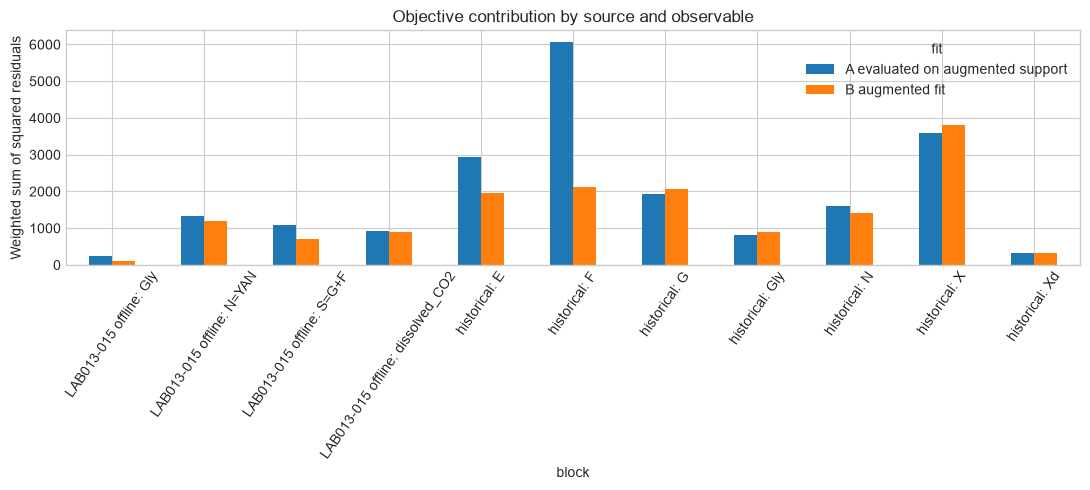

In [13]:
parameter_rows = []
for name in CORE_PARAMETERS:
    low, high = base.PARAMETER_BOUNDS[name]
    a, b = theta_A[name], theta_B[name]
    span_log = math.log(high / low)
    rel_bound_A = min(math.log(a / low), math.log(high / a)) / span_log
    rel_bound_B = min(math.log(b / low), math.log(high / b)) / span_log
    parameter_rows.append({
        "parameter": name, "A_historical": a, "B_augmented": b,
        "percent_change": 100.0 * (b / a - 1.0),
        "lower_bound": low, "upper_bound": high,
        "A_at_bound": rel_bound_A < 0.01, "B_at_bound": rel_bound_B < 0.01,
    })
parameter_comparison = pd.DataFrame(parameter_rows)
display(parameter_comparison)

contribution_B = contribution_table(theta_B, "B augmented fit", True)
all_contributions = pd.concat([
    contribution_A_historical, contribution_A_augmented_support, contribution_B
], ignore_index=True)
display(all_contributions)

hist_A = contribution_A_historical["WSSE"].sum()
hist_B = contribution_B.query("source == 'historical'")["WSSE"].sum()
aug_A = contribution_A_augmented_support["WSSE"].sum()
aug_B = contribution_B["WSSE"].sum()
objective_comparison = pd.DataFrame([
    {"comparison": "historical support", "A_WSSE": hist_A, "B_WSSE": hist_B,
     "percent_change_B_vs_A": 100 * (hist_B / hist_A - 1)},
    {"comparison": "common augmented support", "A_WSSE": aug_A, "B_WSSE": aug_B,
     "percent_change_B_vs_A": 100 * (aug_B / aug_A - 1)},
])
display(objective_comparison)

fig, ax = plt.subplots(figsize=(11, 5))
pivot = (all_contributions[all_contributions["fit"].isin(["A evaluated on augmented support", "B augmented fit"])]
         .assign(block=lambda x: x["source"] + ": " + x["observable"])
         .pivot(index="block", columns="fit", values="WSSE").fillna(0))
pivot.plot.bar(ax=ax)
ax.set_ylabel("Weighted sum of squared residuals")
ax.set_title("Objective contribution by source and observable")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()
plt.show()

## 12. Historical fit before and after adding LAB013–LAB015 offline

,fit,state,n,RMSE
0,A historical,E,44,16.493131
1,A historical,F,91,20.430175
2,A historical,G,91,11.483547
3,A historical,Gly,91,1.104713
4,A historical,N,91,0.062389
5,A historical,X,100,0.559478
6,A historical,Xd,100,0.115533
7,B augmented,E,44,13.390471
8,B augmented,F,91,12.098099
9,B augmented,G,91,11.886804


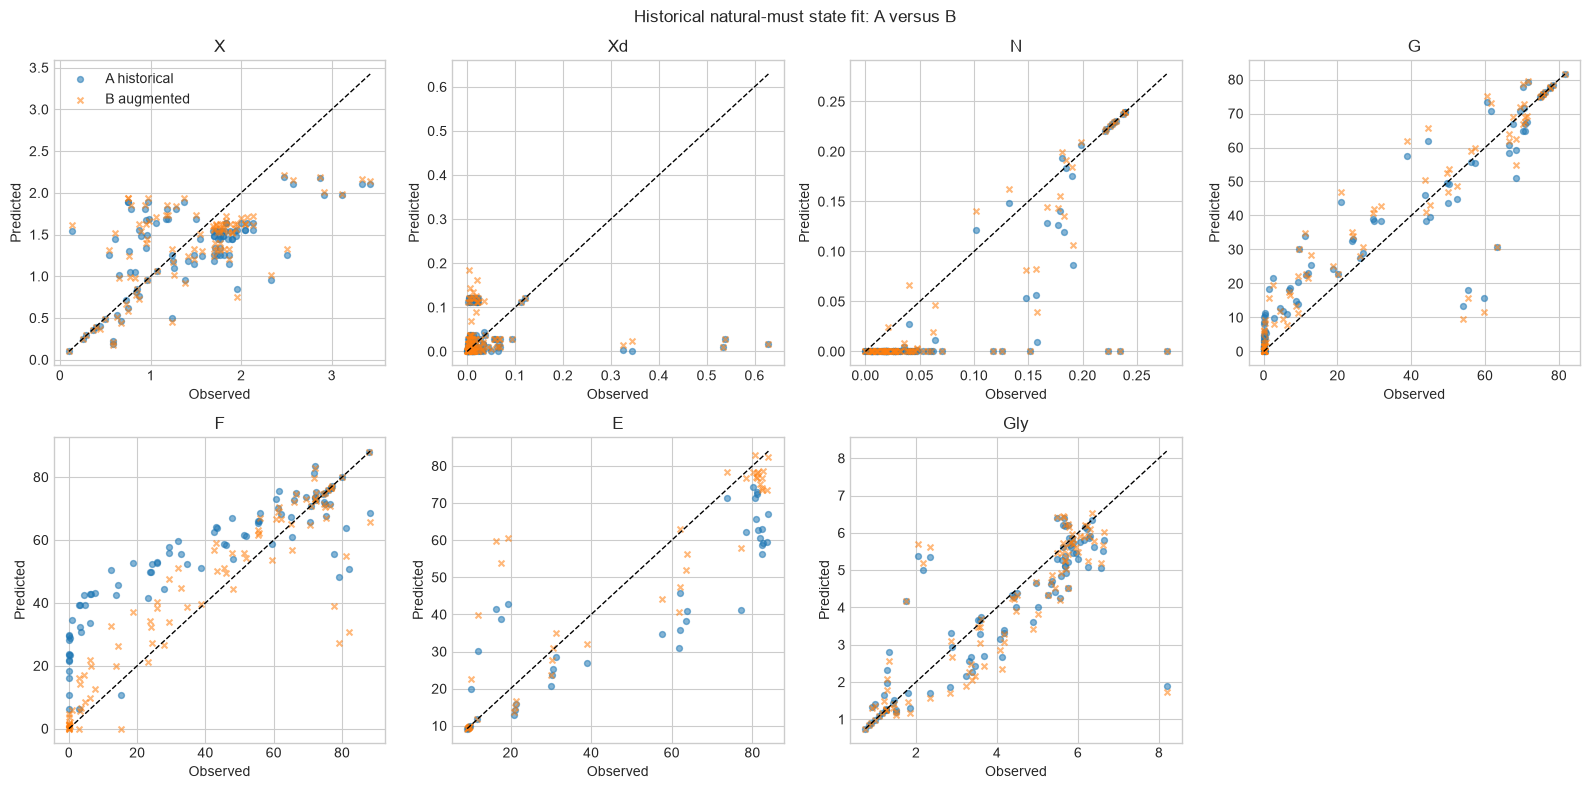

In [14]:
historical_curve_rows = []
for batch in historical_batches:
    for fit_label, theta in (("A historical", theta_A), ("B augmented", theta_B)):
        simulation = base.simulate(batch, theta, batch.time)
        for state in base.STATE_NAMES:
            obs = np.asarray(batch.observations[state], float)
            mask = np.isfinite(obs)
            pred = simulation.loc[batch.time, state].to_numpy(float)
            for time_h, observed, predicted in zip(batch.time[mask], obs[mask], pred[mask]):
                historical_curve_rows.append({"batch": batch.batch, "fit": fit_label, "state": state,
                                              "time_h": time_h, "observed": observed, "predicted": predicted})
historical_curves = pd.DataFrame(historical_curve_rows)
historical_metrics = (historical_curves.assign(sq=lambda x: (x.predicted - x.observed)**2)
                      .groupby(["fit", "state"], as_index=False)
                      .agg(n=("sq", "size"), RMSE=("sq", lambda s: float(np.sqrt(s.mean())))))
display(historical_metrics)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, state in zip(axes.ravel(), base.STATE_NAMES):
    group = historical_curves[historical_curves["state"].eq(state)]
    lim_low = min(group["observed"].min(), group["predicted"].min())
    lim_high = max(group["observed"].max(), group["predicted"].max())
    for label, marker in (("A historical", "o"), ("B augmented", "x")):
        subset = group[group["fit"].eq(label)]
        ax.scatter(subset["observed"], subset["predicted"], s=18, alpha=0.55, marker=marker, label=label)
    ax.plot([lim_low, lim_high], [lim_low, lim_high], "k--", lw=1)
    ax.set_title(state)
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
axes[1, 3].axis("off")
axes[0, 0].legend()
fig.suptitle("Historical natural-must state fit: A versus B")
fig.tight_layout()
plt.show()

## 13. LAB013–LAB015 substrate, nitrogen and glycerol

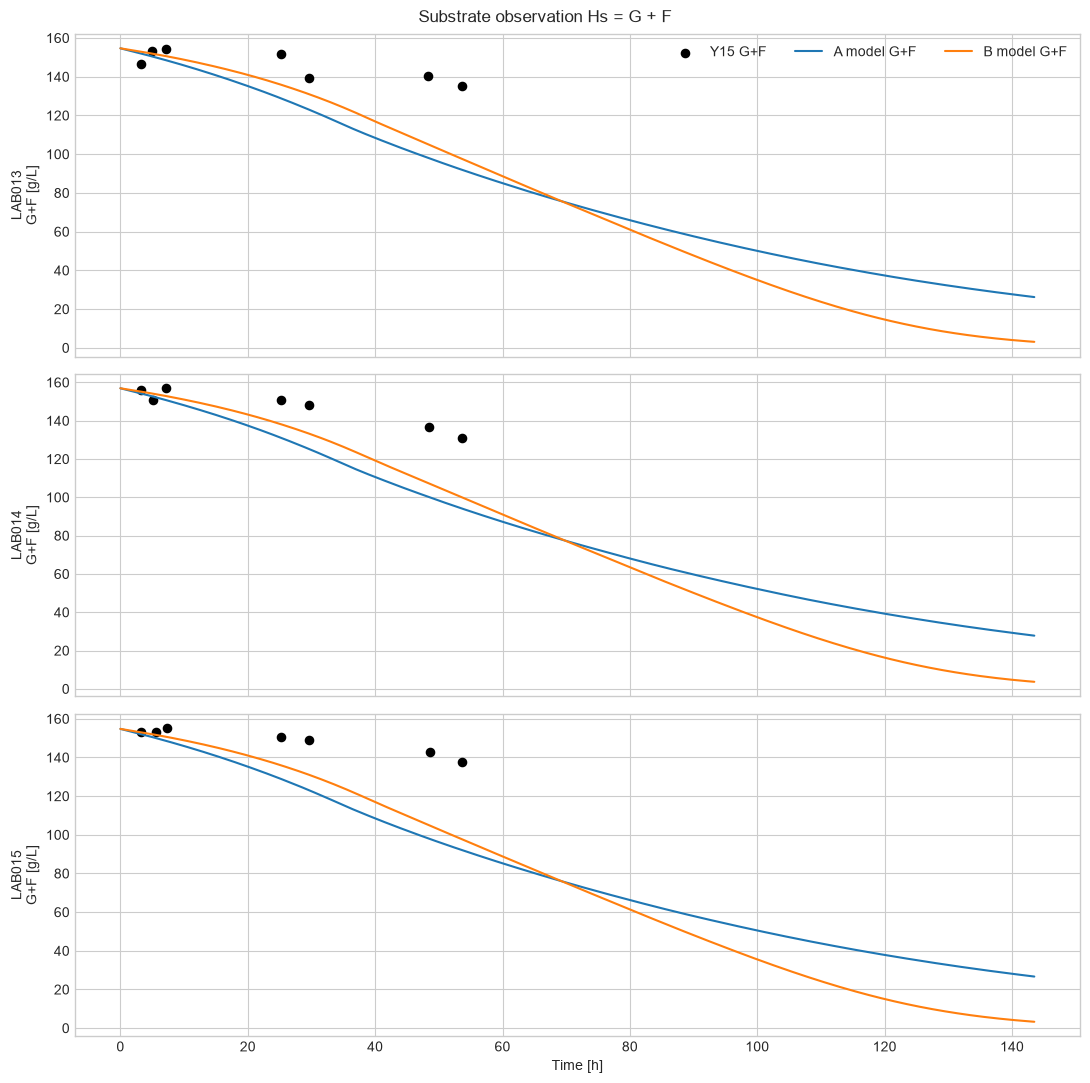

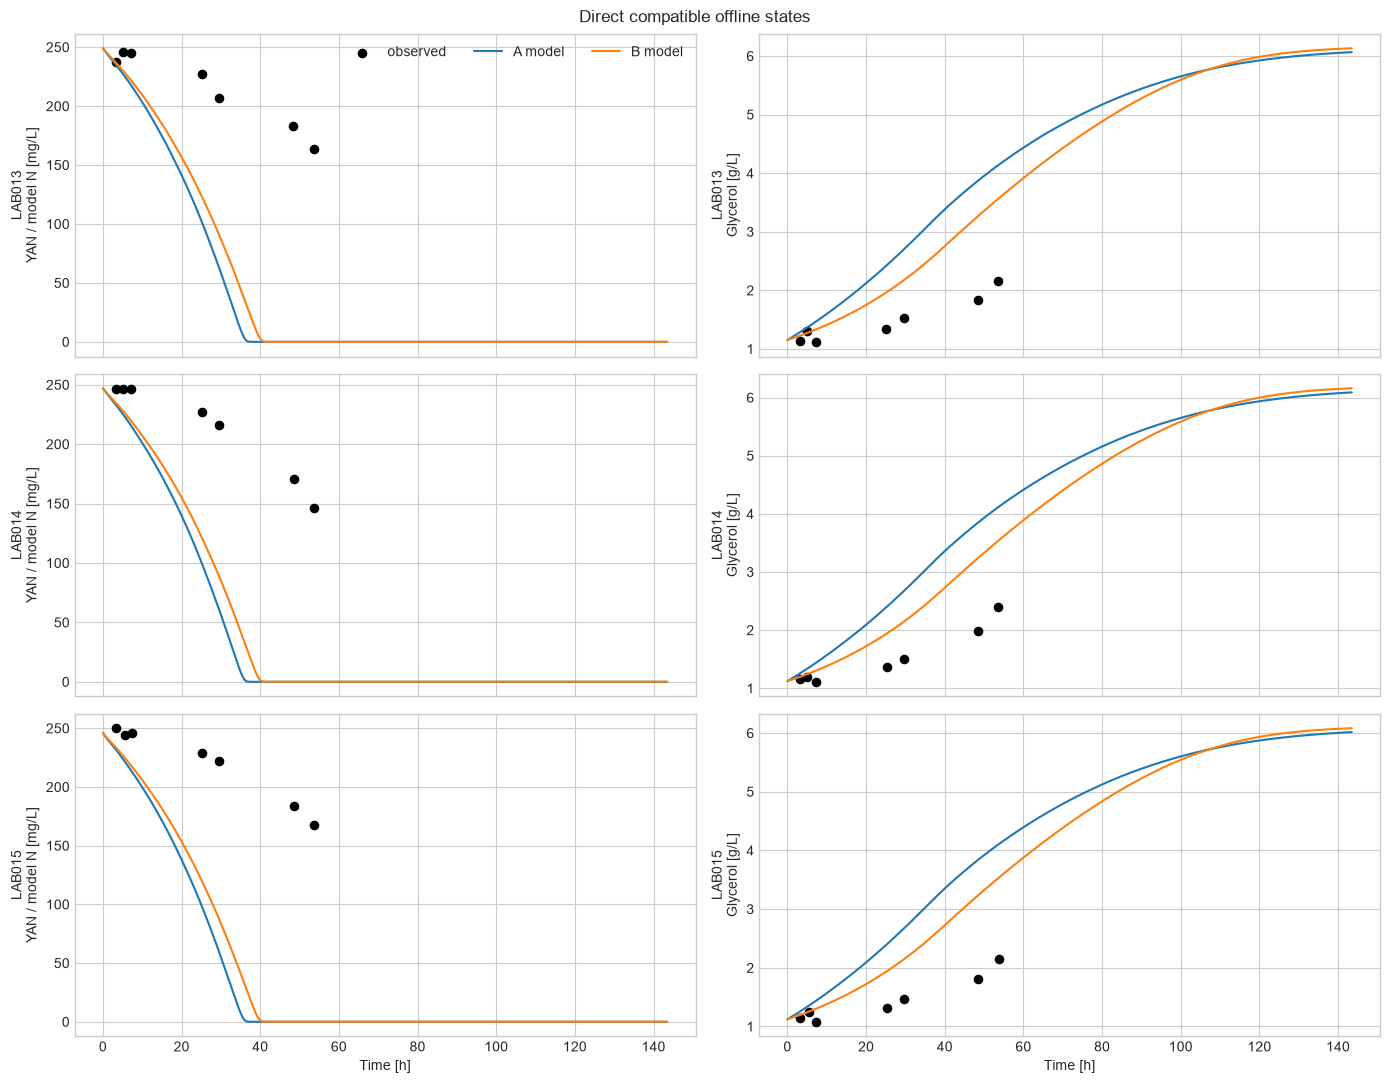

In [15]:
lab_predictions = {}
for lab, batch in lab_batches.items():
    lab_predictions[(lab, "A")] = base.simulate(batch, theta_A, batch.time)
    lab_predictions[(lab, "B")] = base.simulate(batch, theta_B, batch.time)

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for ax, lab in zip(axes, LABS):
    obs = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    ax.scatter(obs["time_h_model"], obs["glucose_fructose_g_L"], color="black", s=35, label="Y15 G+F")
    for fit, color in (("A", "tab:blue"), ("B", "tab:orange")):
        sim = lab_predictions[(lab, fit)]
        ax.plot(sim.index, sim["G"] + sim["F"], color=color, label=f"{fit} model G+F")
    ax.set_ylabel(f"{lab}\nG+F [g/L]")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("Substrate observation Hs = G + F")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for row, lab in enumerate(LABS):
    obs = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    for col, (state, observed_column, factor, ylabel) in enumerate([
        ("N", "YAN_mg_L", 1000.0, "YAN / model N [mg/L]"),
        ("Gly", "glycerol_g_L", 1.0, "Glycerol [g/L]"),
    ]):
        ax = axes[row, col]
        ax.scatter(obs["time_h_model"], obs[observed_column], color="black", s=35, label="observed")
        for fit, color in (("A", "tab:blue"), ("B", "tab:orange")):
            sim = lab_predictions[(lab, fit)]
            ax.plot(sim.index, factor * sim[state], color=color, label=f"{fit} model")
        ax.set_ylabel(f"{lab}\n{ylabel}")
axes[0, 0].legend(ncol=3)
axes[-1, 0].set_xlabel("Time [h]")
axes[-1, 1].set_xlabel("Time [h]")
fig.suptitle("Direct compatible offline states")
fig.tight_layout()
plt.show()

In [16]:
lab_fit_metrics_rows = []
for lab in LABS:
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)].sort_values("time_h_model")
    for fit, theta in (("A", theta_A), ("B", theta_B)):
        sim = lab_predictions[(lab, fit)]
        t = dyn["time_h_model"].to_numpy(float)
        values = {
            "S=G+F": (dyn["glucose_fructose_g_L"].to_numpy(float), np.interp(t, sim.index, sim.G + sim.F), "g/L"),
            "N=YAN": (dyn["YAN_mg_L"].to_numpy(float), 1000*np.interp(t, sim.index, sim.N), "mg/L"),
            "Gly": (dyn["glycerol_g_L"].to_numpy(float), np.interp(t, sim.index, sim.Gly), "g/L"),
        }
        for observable, (observed, predicted, unit) in values.items():
            lab_fit_metrics_rows.append({"lab_id": lab, "fit": fit, "observable": observable, "unit": unit,
                                         "n": len(observed), "RMSE": float(np.sqrt(np.mean((predicted-observed)**2))),
                                         "bias_pred_minus_obs": float(np.mean(predicted-observed))})
lab_fit_metrics = pd.DataFrame(lab_fit_metrics_rows)
display(lab_fit_metrics)

,lab_id,fit,observable,unit,n,RMSE,bias_pred_minus_obs
0,LAB013,A,S=G+F,g/L,7,25.305953,-18.210889
1,LAB013,A,N=YAN,mg/L,7,118.360965,-94.893123
2,LAB013,A,Gly,g/L,7,1.237317,0.975146
3,LAB013,B,S=G+F,g/L,7,20.729299,-13.610973
4,LAB013,B,N=YAN,mg/L,7,110.519305,-86.580995
5,LAB013,B,Gly,g/L,7,0.832698,0.625062
6,LAB014,A,S=G+F,g/L,7,22.787651,-17.364026
7,LAB014,A,N=YAN,mg/L,7,114.987700,-94.884241
8,LAB014,A,Gly,g/L,7,1.137343,0.910106
9,LAB014,B,S=G+F,g/L,7,17.854410,-12.719939


## 14. Dissolved CO$_2$ and validation-only variables

Dissolved CO$_2$ after time zero enters B through the existing latent pool. Its
initial value remains validation-only. O$_2$, Brix, density, ammonia, and PAN are
shown without forcing unsupported observation equations. Missing O$_2$ values
remain NaN.

,lab_id,fit,n_fit_points,RMSE_g_L,bias_g_L
0,LAB013,A,6,1.172057,-1.039912
1,LAB013,B,6,1.139506,-1.001534
2,LAB014,A,6,0.833701,-0.788494
3,LAB014,B,6,0.787990,-0.746905
4,LAB015,A,6,1.250458,-1.133160
5,LAB015,B,6,1.248179,-1.131390


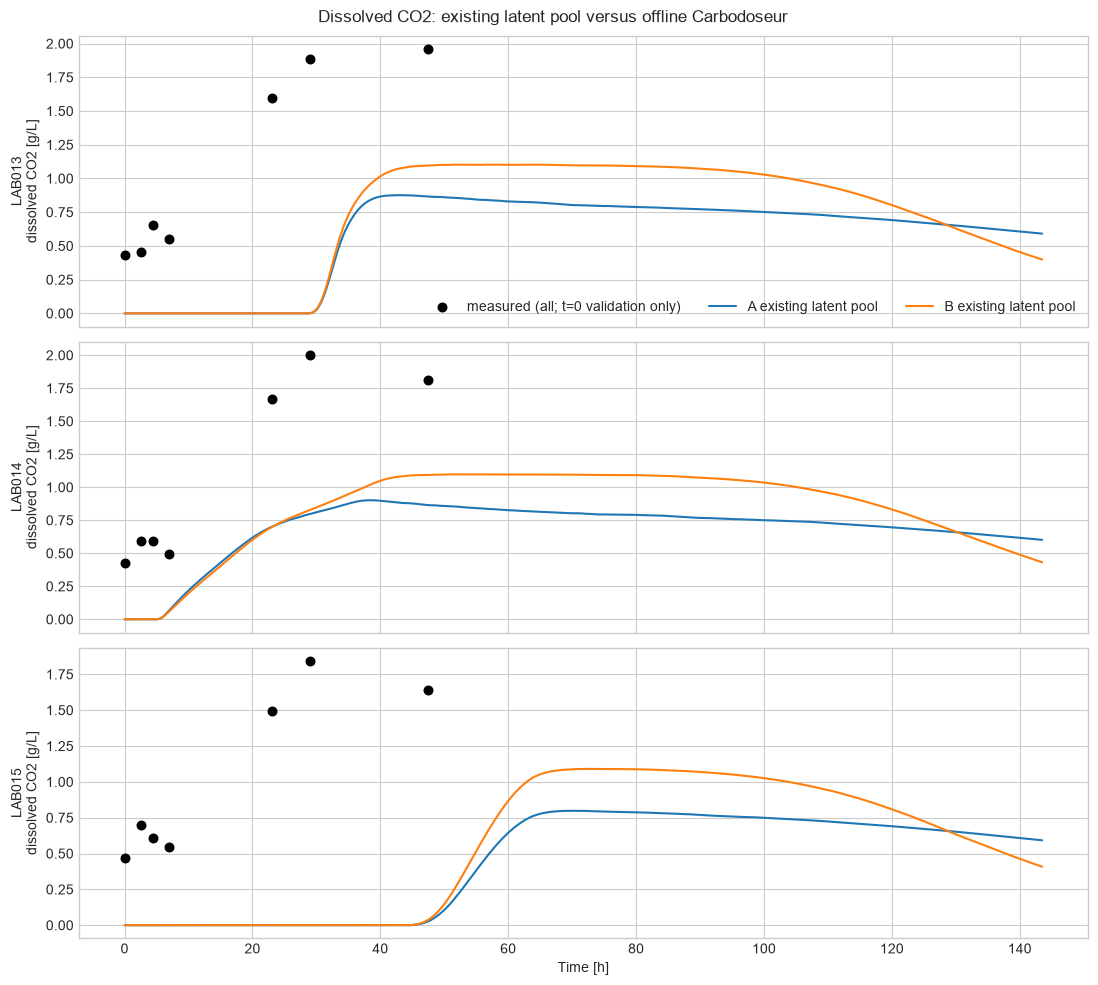

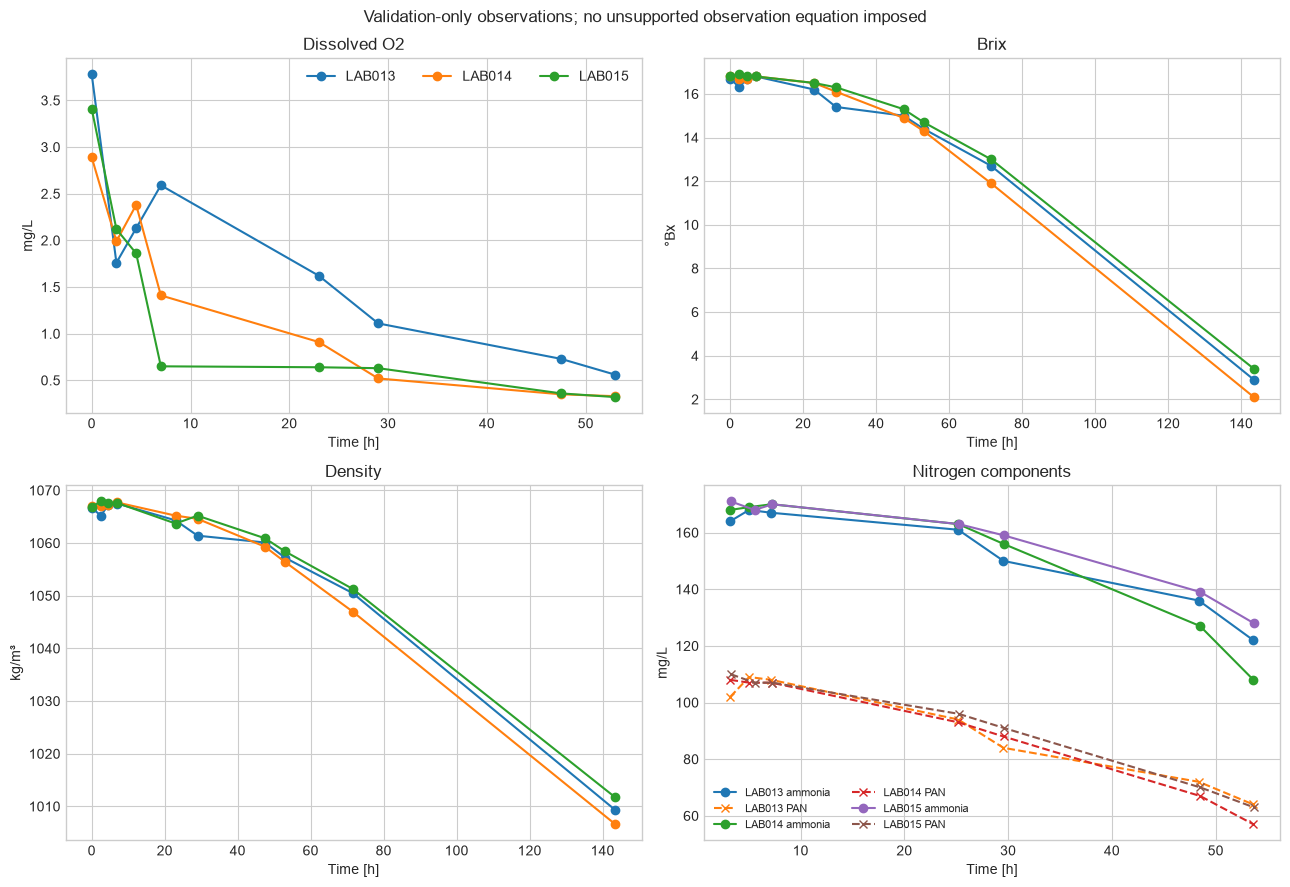

In [17]:
cache_A_lab = build_lab_driver_cache(theta_A)
cache_B_lab = build_lab_driver_cache(theta_B)
dissolved_metric_rows = []
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, lab in zip(axes, LABS):
    off = offline[offline["lab_id"].eq(lab)].sort_values("time_h_model")
    ax.scatter(off["time_h_model"], off["CO2_dissolved_actualT_mg_L"] * 1e-3,
               color="black", s=38, label="measured (all; t=0 validation only)")
    for fit, cache, color in (("A", cache_A_lab, "tab:blue"), ("B", cache_B_lab, "tab:orange")):
        dissolved, *_ = dissolved_pool_grid(cache[lab])
        ax.plot(cache[lab].time_h, dissolved, color=color, label=f"{fit} existing latent pool")
        used = off[off["CO2_dissolved_actualT_mg_L"].notna() & off["time_h_model"].gt(0)]
        pred = np.interp(used["time_h_model"], cache[lab].time_h, dissolved)
        obs = used["CO2_dissolved_actualT_mg_L"].to_numpy(float) * 1e-3
        dissolved_metric_rows.append({"lab_id": lab, "fit": fit, "n_fit_points": len(obs),
                                      "RMSE_g_L": float(np.sqrt(np.mean((pred-obs)**2))),
                                      "bias_g_L": float(np.mean(pred-obs))})
    ax.set_ylabel(f"{lab}\ndissolved CO2 [g/L]")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("Dissolved CO2: existing latent pool versus offline Carbodoseur")
fig.tight_layout()
plt.show()
dissolved_metrics = pd.DataFrame(dissolved_metric_rows)
display(dissolved_metrics)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for lab in LABS:
    off = offline[offline["lab_id"].eq(lab)]
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)]
    axes[0, 0].plot(off["time_h_model"], off["DO_value"], marker="o", label=lab)
    axes[0, 1].plot(off["time_h_model"], off["brix_degBx"], marker="o", label=lab)
    axes[1, 0].plot(off["time_h_model"], off["rho_value"], marker="o", label=lab)
    axes[1, 1].plot(dyn["time_h_model"], dyn["ammonia_mg_L"], marker="o", label=f"{lab} ammonia")
    axes[1, 1].plot(dyn["time_h_model"], dyn["PAN_mg_L"], marker="x", ls="--", label=f"{lab} PAN")
for ax, title, ylabel in zip(axes.ravel(), ["Dissolved O2", "Brix", "Density", "Nitrogen components"],
                             ["mg/L", "°Bx", "kg/m³", "mg/L"]):
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Time [h]")
axes[0, 0].legend(ncol=3)
axes[1, 1].legend(ncol=2, fontsize=8)
fig.suptitle("Validation-only observations; no unsupported observation equation imposed")
fig.tight_layout()
plt.show()
assert offline.groupby("lab_id")["DO_value"].apply(lambda s: s.isna().sum()).eq(2).all()

## 15. Comparison with recorded historical gas-phase CO$_2$

The existing natural-must CO$_2$ observation-layer parameters are held fixed.
Rebuilding its upstream drivers with A and B tests whether the augmented biological
fit changes agreement with the recorded historical calibration and LAB012 holdout. These gas data
remain validation-only in this notebook.

,upstream_fit,batch,role,n,rmse_g_l_h,nrmse_peak,correlation,integral_ratio_pred_over_observed_lower_bound
0,A historical,LAB004,calibration,97,0.157291,0.194948,0.999988,0.956651
1,A historical,LAB005,calibration,119,0.075453,0.106871,0.999974,1.092687
2,A historical,LAB006,calibration,139,0.087672,0.214141,0.999999,1.360551
3,A historical,LAB007,calibration,101,0.172832,0.209016,0.999932,0.902200
4,A historical,LAB008,calibration,114,0.090616,0.133800,0.999908,1.065078
5,A historical,LAB010,calibration,84,0.052161,0.139209,0.998658,1.153160
6,A historical,LAB011,calibration,76,0.443024,0.346607,0.999810,0.465974
7,A historical,LAB012,internal_holdout,98,0.318335,0.261581,0.999719,0.668023
8,B augmented,LAB004,calibration,97,0.239427,0.296748,0.999995,1.245118
9,B augmented,LAB005,calibration,119,0.259437,0.367467,0.999979,1.391964


,upstream_fit,role,mean_RMSE_g_L_h,mean_NRMSE_peak,mean_correlation
0,A historical,calibration,0.154150,0.192085,0.999753
1,A historical,internal_holdout,0.318335,0.261581,0.999719
2,B augmented,calibration,0.246834,0.348486,0.997076
3,B augmented,internal_holdout,0.457087,0.375596,0.998538


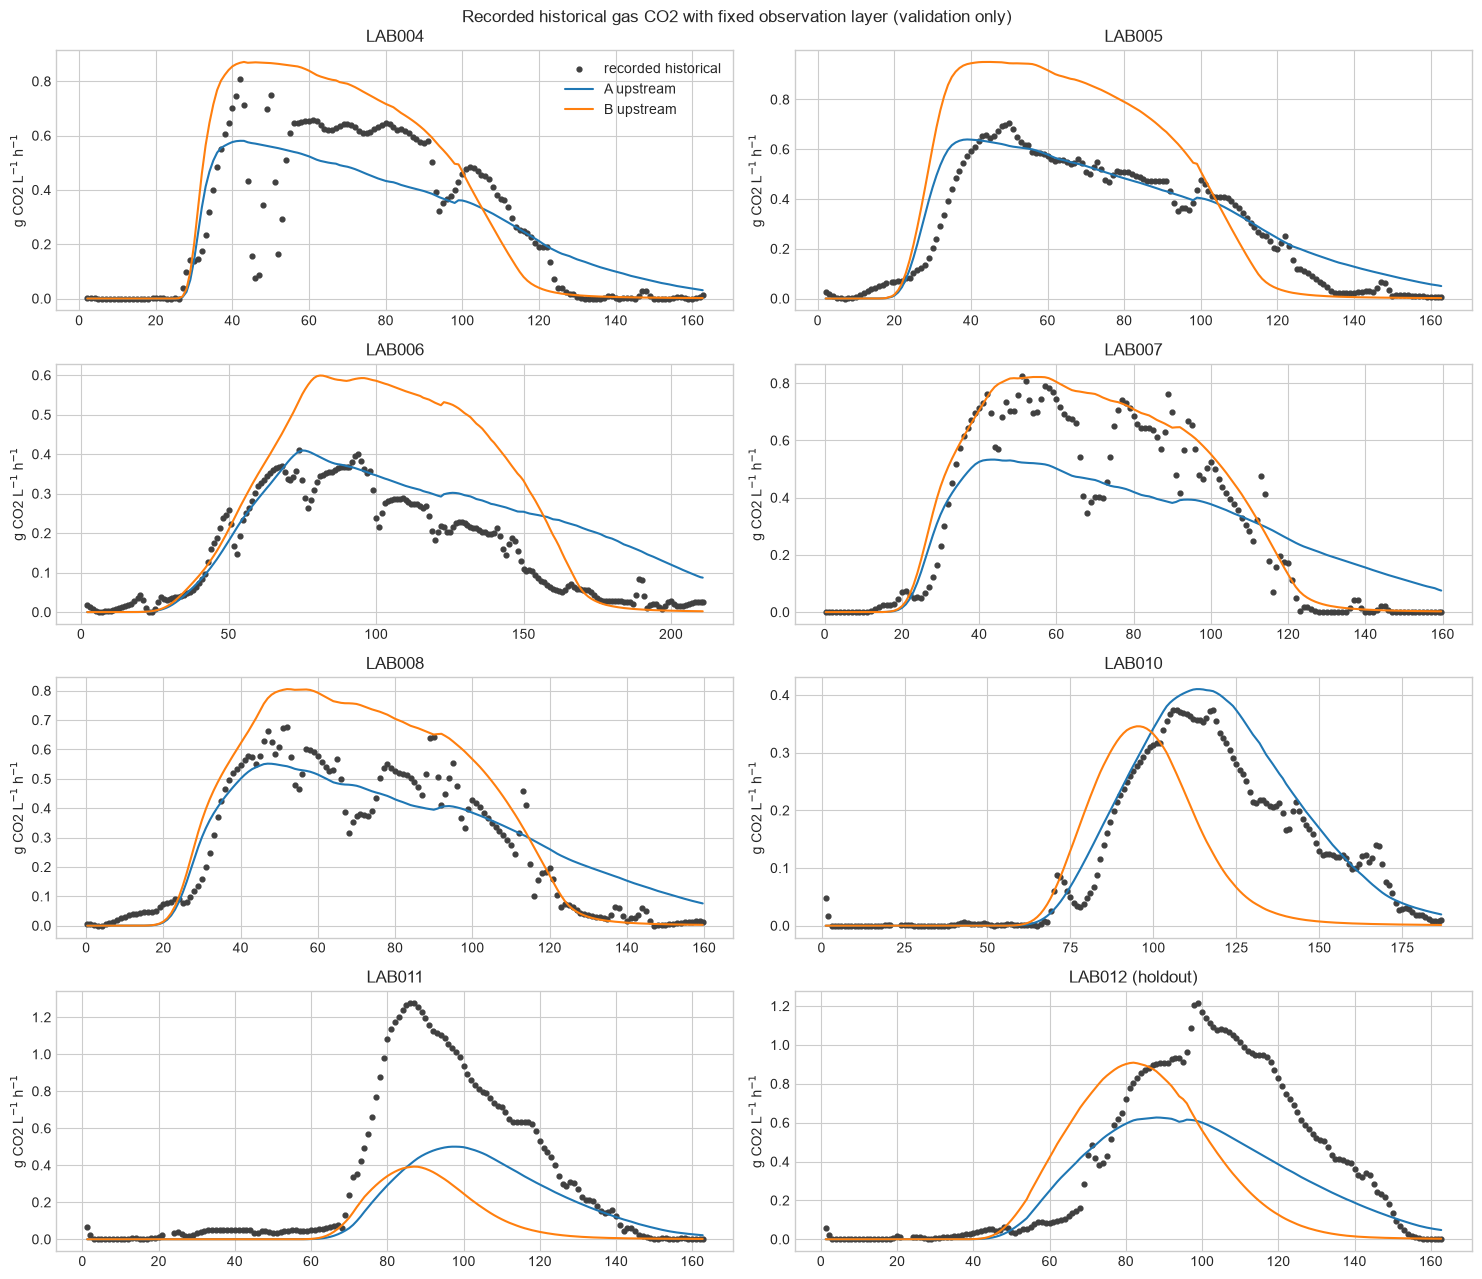

In [18]:
historical_gas_observations = pd.read_csv(requested["historical_co2"])
historical_gas_observations = historical_gas_observations[
    historical_gas_observations["matrix"].eq("natural")
].copy()
pulse_schedule = pd.read_csv(CO2_RESULTS / "effective_nutrient_pulses.csv")
pulse_schedule = pulse_schedule[pulse_schedule["matrix"].eq("natural")].rename(
    columns={"pulse_time_h": "model_pulse_time_h"}
)
historical_batches_for_gas = co2_layer.override_natural_nutrient_pulses(historical_batches, pulse_schedule)
historical_batch_map = {batch.batch: batch for batch in historical_batches_for_gas}
cache_A_hist, _ = co2_layer.build_driver_cache(
    historical_batch_map, {"natural": theta_A}, historical_gas_observations
)
cache_B_hist, _ = co2_layer.build_driver_cache(
    historical_batch_map, {"natural": theta_B}, historical_gas_observations
)
fixed_fit = {"natural": {**fixed_co2_parameters, "matrix_gain": fixed_co2_parameters["matrix_gain"]}}
pred_A_hist_gas, metrics_A_hist_gas, _ = co2_layer.predict_and_score(
    fixed_fit, historical_gas_observations, cache_A_hist
)
pred_B_hist_gas, metrics_B_hist_gas, _ = co2_layer.predict_and_score(
    fixed_fit, historical_gas_observations, cache_B_hist
)
historical_gas_metrics = pd.concat([
    metrics_A_hist_gas.assign(upstream_fit="A historical"),
    metrics_B_hist_gas.assign(upstream_fit="B augmented"),
], ignore_index=True)
display(historical_gas_metrics[["upstream_fit", "batch", "role", "n", "rmse_g_l_h",
                                "nrmse_peak", "correlation", "integral_ratio_pred_over_observed_lower_bound"]])

gas_preservation = (historical_gas_metrics.groupby(["upstream_fit", "role"], as_index=False)
                    .agg(mean_RMSE_g_L_h=("rmse_g_l_h", "mean"),
                         mean_NRMSE_peak=("nrmse_peak", "mean"),
                         mean_correlation=("correlation", "mean")))
display(gas_preservation)

joined_hist_predictions = pd.concat([
    pred_A_hist_gas.assign(upstream_fit="A"), pred_B_hist_gas.assign(upstream_fit="B")
], ignore_index=True)
batches_to_plot = sorted(joined_hist_predictions["batch"].unique())
fig, axes = plt.subplots(4, 2, figsize=(15, 13), sharex=False)
for ax, batch_name in zip(axes.ravel(), batches_to_plot):
    group = joined_hist_predictions[joined_hist_predictions["batch"].eq(batch_name)]
    observed = group[group["upstream_fit"].eq("A")]
    ax.scatter(observed["time_h"], observed["observed_g_l_h"], color="0.25", s=12, label="recorded historical")
    for fit, color in (("A", "tab:blue"), ("B", "tab:orange")):
        curve = group[group["upstream_fit"].eq(fit)]
        ax.plot(curve["time_h"], curve["predicted_g_l_h"], color=color, label=f"{fit} upstream")
    ax.set_title(batch_name + (" (holdout)" if batch_name == co2_layer.HOLDOUTS["natural"] else ""))
    ax.set_ylabel("g CO2 L$^{-1}$ h$^{-1}$")
axes[0, 0].legend()
fig.suptitle("Recorded historical gas CO2 with fixed observation layer (validation only)")
fig.tight_layout()
plt.show()

## 16. LAB013–LAB015 gas-phase CO$_2$ qualitative overlay

The same fixed observation layer is used only to show the experimental discrepancy.
No RMSE or other gas metric from LAB013–LAB015 is used to choose A or B.

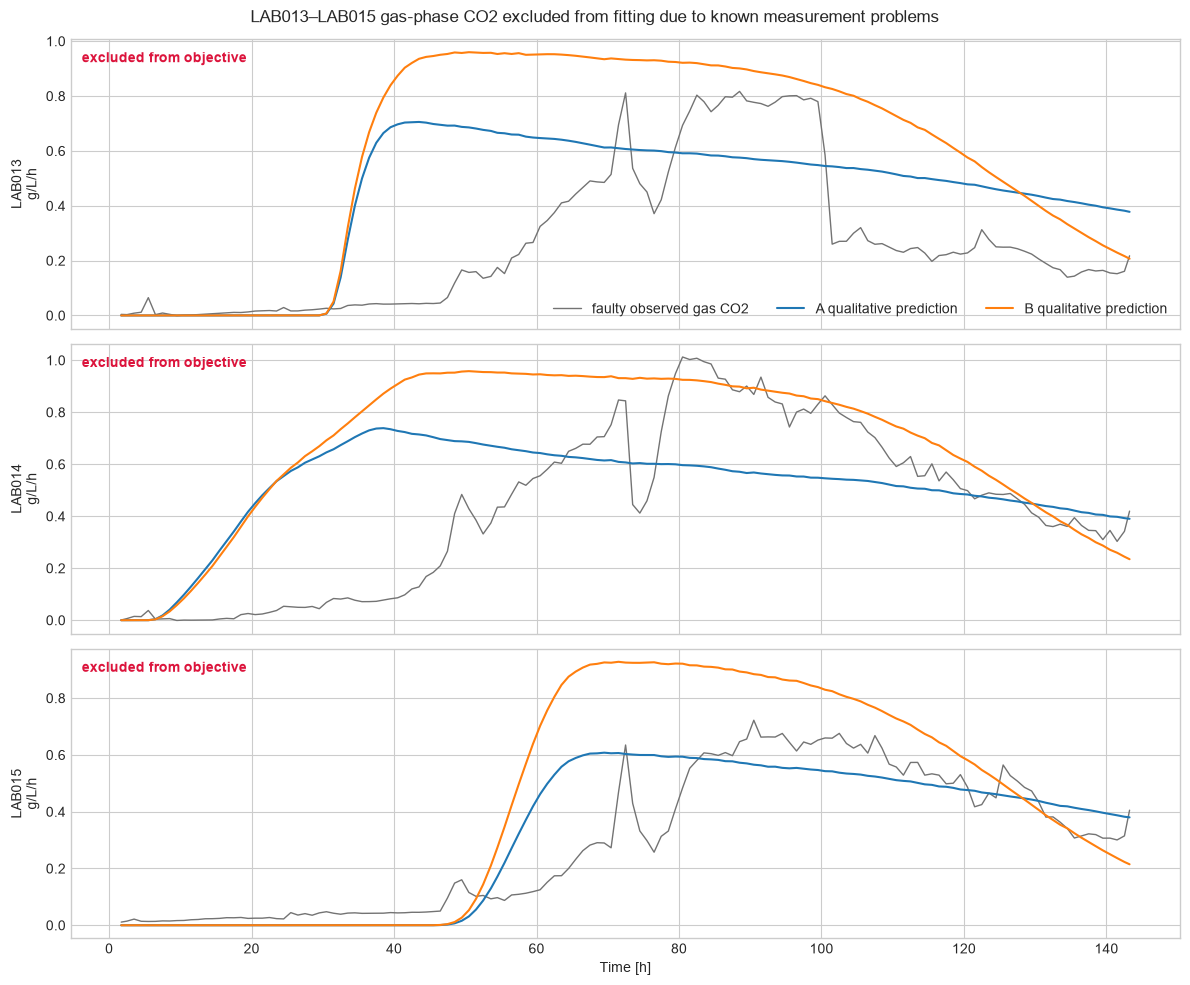

In [19]:
diagnostic_support = gas_reference.rename(columns={"lab_id": "batch", "t_h": "t_h"}).copy()
diagnostic_support["matrix"] = "natural"
diagnostic_support["calibratable"] = True  # required only for cache construction, never for fitting
diagnostic_support["chemistry_last_h"] = diagnostic_support["batch"].map(
    {lab: float(batch.time.max()) for lab, batch in lab_batches.items()}
)
diag_cache_A, _ = co2_layer.build_driver_cache(lab_batches, {"natural": theta_A}, diagnostic_support)
diag_cache_B, _ = co2_layer.build_driver_cache(lab_batches, {"natural": theta_B}, diagnostic_support)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, lab in zip(axes, LABS):
    observed = gas_reference[gas_reference["lab_id"].eq(lab)]
    ax.plot(observed["t_h"], observed["co2_rate_g_l_h"], color="0.45", lw=1, label="faulty observed gas CO2")
    for fit, cache, color in (("A", diag_cache_A, "tab:blue"), ("B", diag_cache_B, "tab:orange")):
        raw = co2_layer.raw_qgas_prediction(
            cache[lab], fixed_co2_parameters["kCO2_release_h"], fixed_co2_parameters["CO2sat_scale"],
            fixed_co2_parameters["O2_qmax_mg_gdw_h"], fixed_co2_parameters["O2_initial_scale"],
            chemistry_aligned=True, nitrogen_boost_transition=True,
            pulse_t_rise_h=fixed_co2_parameters["pulse_t_rise_h"],
            pulse_activity_gain=fixed_co2_parameters["pulse_activity_gain"], continuous_release=True,
            bounded_chemical_activation=True,
            chem_activation_start_fraction=fixed_co2_parameters["chem_activation_start_fraction"],
            chem_activation_duration_fraction=fixed_co2_parameters["chem_activation_duration_fraction"],
        )
        ax.plot(cache[lab].observation_time_h, fixed_co2_parameters["matrix_gain"] * raw,
                color=color, label=f"{fit} qualitative prediction")
    ax.text(0.01, 0.92, "excluded from objective", transform=ax.transAxes, color="crimson", weight="bold")
    ax.set_ylabel(f"{lab}\ng/L/h")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("LAB013–LAB015 gas-phase CO2 excluded from fitting due to known measurement problems")
fig.tight_layout()
plt.show()

## 17. Practical identifiability and parameter compensation

Jacobians are with respect to log-parameters and scaled residuals. The comparison
`A historical` versus `A + LAB offline at the same theta` isolates the information
contributed by the new measurements from movement of the optimum. `B augmented`
then reports the local geometry at the new solution. Ridge-stabilized standard-error
proxies and correlations are local diagnostics, not formal confidence intervals.
The same ridge, fixed from the historical FIM scale, is used in all three cases.
A bound alone is reported as a boundary solution, not automatically as structural
non-identifiability.

,label,rank_1e-8,condition_number,smallest_singular_value,fixed_FIM_ridge,max_abs_parameter_correlation,median_log_parameter_SE_proxy
0,A historical,11,100616.002205,0.002257,0.00008,0.997615,0.101980
1,A + LAB offline at same theta,11,99693.231578,0.002317,0.00008,0.996482,0.096409
2,B augmented frozen,11,25125.312106,0.009662,0.00008,0.989177,0.182522


,parameter,A_historical_SE_proxy,A_plus_LAB_same_theta_SE_proxy,B_augmented_SE_proxy,information_gain_percent_at_same_theta
0,mu0,0.012876,0.012186,0.010971,5.360327
1,qN,0.014461,0.013318,0.012513,7.904337
2,betaG0,0.099122,0.096409,0.076181,2.736395
3,betaF0,0.632953,0.515801,0.424610,18.508864
4,qEG,0.061381,0.046189,0.032735,24.751582
5,qEF,0.614569,0.501911,0.404222,18.331286
6,iG,0.271668,0.238353,0.358641,12.262970
7,iE,0.101980,0.074700,0.182522,26.750476
8,Kd0,11.366189,11.291469,0.412394,0.657389
9,gammaG0,0.063447,0.048572,0.047591,23.445344


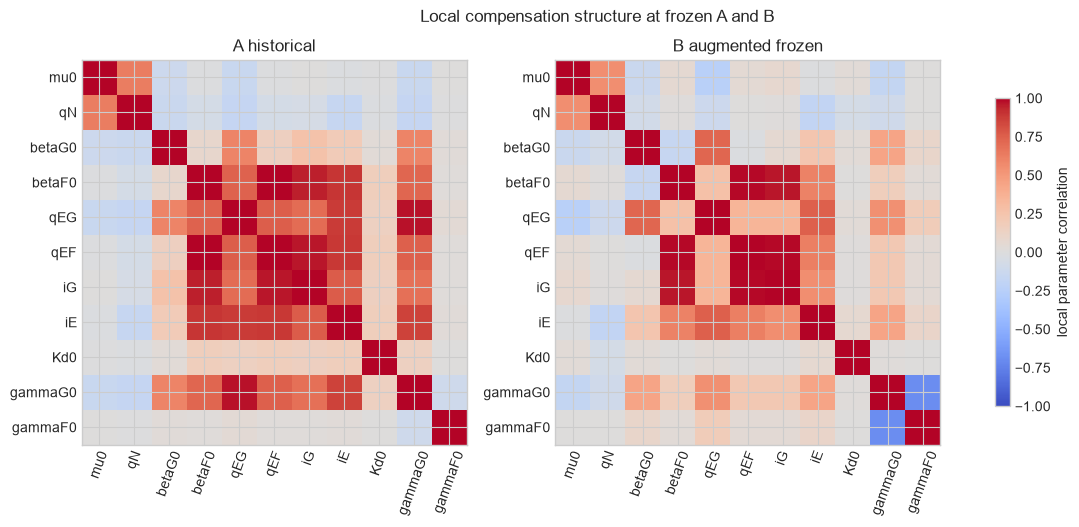

In [20]:
def finite_difference_jacobian(theta, residual_function, parameters=CORE_PARAMETERS, step=0.03):
    base_residual = residual_function(theta)
    jacobian = np.zeros((len(base_residual), len(parameters)))
    for j, name in enumerate(parameters):
        plus, minus = dict(theta), dict(theta)
        low, high = base.PARAMETER_BOUNDS[name]
        plus[name] = float(np.clip(theta[name] * math.exp(step), low, high))
        minus[name] = float(np.clip(theta[name] * math.exp(-step), low, high))
        denominator = math.log(plus[name]) - math.log(minus[name])
        jacobian[:, j] = (residual_function(plus) - residual_function(minus)) / denominator
    return jacobian

def lab_only_residual(theta):
    blocks = scaled_residual_blocks(theta, True)
    return np.concatenate([
        value for (source, _), value in sorted(blocks.items())
        if source == "LAB013-015 offline"
    ])

J_hist_A, _ = base.build_jacobian(theta_A, CORE_PARAMETERS, historical_batches, step=0.03)
J_lab_A = finite_difference_jacobian(theta_A, lab_only_residual)
J_aug_at_A = np.vstack([J_hist_A, J_lab_A])
J_aug_at_B = finite_difference_jacobian(theta_B, lambda theta: objective_residual(theta, True))
FIM_RIDGE = 1e-8 * max(float(np.trace(J_hist_A.T @ J_hist_A)) / len(CORE_PARAMETERS), 1.0)

def fim_diagnostics(label, jacobian):
    singular = np.linalg.svd(jacobian, compute_uv=False)
    fim = jacobian.T @ jacobian
    covariance_proxy = np.linalg.inv(fim + FIM_RIDGE * np.eye(len(CORE_PARAMETERS)))
    se_proxy = np.sqrt(np.maximum(np.diag(covariance_proxy), 0.0))
    denom = np.sqrt(np.outer(np.diag(covariance_proxy), np.diag(covariance_proxy)))
    corr = np.divide(covariance_proxy, denom, out=np.zeros_like(covariance_proxy), where=denom > 0)
    offdiag = np.abs(corr - np.eye(len(corr)))
    threshold = singular[0] * 1e-8
    return {
        "label": label, "jacobian": jacobian, "fim": fim, "singular": singular,
        "se_proxy": se_proxy, "corr": corr,
        "rank_1e-8": int(np.sum(singular > threshold)),
        "condition_number": float(singular[0] / singular[-1]) if singular[-1] > 0 else np.inf,
        "smallest_singular_value": float(singular[-1]),
        "fixed_FIM_ridge": FIM_RIDGE,
        "max_abs_parameter_correlation": float(offdiag.max()),
        "median_log_parameter_SE_proxy": float(np.median(se_proxy)),
    }

identifiability_objects = [
    fim_diagnostics("A historical", J_hist_A),
    fim_diagnostics("A + LAB offline at same theta", J_aug_at_A),
    fim_diagnostics("B augmented frozen", J_aug_at_B),
]
identifiability_summary = pd.DataFrame([
    {key: value for key, value in item.items()
     if key not in {"jacobian", "fim", "singular", "se_proxy", "corr"}}
    for item in identifiability_objects
])
display(identifiability_summary)

se_comparison = pd.DataFrame({
    "parameter": CORE_PARAMETERS,
    "A_historical_SE_proxy": identifiability_objects[0]["se_proxy"],
    "A_plus_LAB_same_theta_SE_proxy": identifiability_objects[1]["se_proxy"],
    "B_augmented_SE_proxy": identifiability_objects[2]["se_proxy"],
})
se_comparison["information_gain_percent_at_same_theta"] = 100 * (
    1 - se_comparison["A_plus_LAB_same_theta_SE_proxy"] / se_comparison["A_historical_SE_proxy"]
)
display(se_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, item in zip(axes, (identifiability_objects[0], identifiability_objects[2])):
    image = ax.imshow(item["corr"], vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(CORE_PARAMETERS)), CORE_PARAMETERS, rotation=70)
    ax.set_yticks(range(len(CORE_PARAMETERS)), CORE_PARAMETERS)
    ax.set_title(item["label"])
fig.colorbar(image, ax=axes, shrink=0.8, label="local parameter correlation")
fig.suptitle("Local compensation structure at frozen A and B")
plt.show()

## Information added by LAB013–LAB015 offline measurements

In [21]:
info_A = identifiability_summary[identifiability_summary["label"].eq("A historical")].iloc[0]
info_added = identifiability_summary[identifiability_summary["label"].eq("A + LAB offline at same theta")].iloc[0]
n_se_improved = int((se_comparison["information_gain_percent_at_same_theta"] > 0).sum())
median_info_gain = float(se_comparison["information_gain_percent_at_same_theta"].median())
max_parameter_change = parameter_comparison.loc[parameter_comparison["percent_change"].abs().idxmax()]
hist_change = float(objective_comparison.loc[objective_comparison["comparison"].eq("historical support"), "percent_change_B_vs_A"].iloc[0])
total_change = float(objective_comparison.loc[objective_comparison["comparison"].eq("common augmented support"), "percent_change_B_vs_A"].iloc[0])
bound_A = parameter_comparison.query("A_at_bound")["parameter"].tolist()
bound_B = parameter_comparison.query("B_at_bound")["parameter"].tolist()

display(Markdown(f"""
The augmented data add {int(contribution_A_augmented_support.query("source == 'LAB013-015 offline'")["n"].sum())}
scaled residuals: total substrate, repository-compatible YAN, glycerol, and dynamic
dissolved CO$_2$. At the same parameter point, the smallest singular value changes
from **{info_A.smallest_singular_value:.3g}** to **{info_added.smallest_singular_value:.3g}**;
{n_se_improved}/{len(CORE_PARAMETERS)} local log-parameter uncertainty proxies decrease,
with a median reduction of **{median_info_gain:.1f}%**.

After refitting, the common augmented-support objective changes by **{total_change:.1f}%**,
while the historical-only contribution changes by **{hist_change:.1f}%**. The largest
parameter movement is `{max_parameter_change.parameter}`
({max_parameter_change.percent_change:+.1f}%). Boundary solutions change from
`{bound_A}` in A to `{bound_B}` in B. These diagnostics distinguish added local
information from a claim of structural identifiability. Because A is the saved prior
estimate and B is newly optimized, objective changes combine parameter movement with
the added residual block; the same-theta Jacobian comparison is the isolated measure
of information added by LAB013–LAB015.
"""))


The augmented data add 81
scaled residuals: total substrate, repository-compatible YAN, glycerol, and dynamic
dissolved CO$_2$. At the same parameter point, the smallest singular value changes
from **0.00226** to **0.00232**;
11/11 local log-parameter uncertainty proxies decrease,
with a median reduction of **12.3%**.

After refitting, the common augmented-support objective changes by **-25.6%**,
while the historical-only contribution changes by **-27.0%**. The largest
parameter movement is `iE`
(-89.9%). Boundary solutions change from
`['gammaF0']` in A to `['gammaF0']` in B. These diagnostics distinguish added local
information from a claim of structural identifiability. Because A is the saved prior
estimate and B is newly optimized, objective changes combine parameter movement with
the added residual block; the same-theta Jacobian comparison is the isolated measure
of information added by LAB013–LAB015.


## 18. Frozen diagnostic objective decomposition

`theta_A` and `theta_B` are evaluated without optimization. Historical gas CO$_2$
was not a term of the biological A/B objective, so its $J$ below is explicitly a
**counterfactual diagnostic contribution** calculated with the existing CO$_2$-layer
normalization: per-batch scale `max(0.04, 10% of observed peak)`, equal-batch
division by `sqrt(n_batch)`, left-censored hinge residuals, and the existing onset
and post-pulse timing residuals. The observation-layer parameters and matrix gain
remain fixed.

In [22]:
TRUSTED_HISTORICAL_GAS_BATCHES = tuple(sorted(
    historical_gas_observations.loc[
        historical_gas_observations["calibratable"].astype(bool), "batch"
    ].unique()
))

def fixed_historical_co2_residual(predictions, cache):
    residuals = []
    for batch_name in TRUSTED_HISTORICAL_GAS_BATCHES:
        group = historical_gas_observations[
            historical_gas_observations["batch"].eq(batch_name)
        ].sort_values("t_h")
        curve = predictions[predictions["batch"].eq(batch_name)].sort_values("time_h")
        observed = group["co2_rate_g_l_h"].to_numpy(float)
        predicted = curve["predicted_g_l_h"].to_numpy(float)
        censored = group["left_censored"].astype(bool).to_numpy()
        sigma = max(0.04, 0.10 * float(np.nanmax(observed)))
        pieces = []
        if (~censored).any():
            pieces.append((predicted[~censored] - observed[~censored]) / sigma)
        if censored.any():
            limit = group["detection_limit_g_l_h"].to_numpy(float)[censored]
            pieces.append(np.maximum(predicted[censored] - limit, 0.0) / sigma)
        residuals.append(np.concatenate(pieces) / math.sqrt(len(group)))

        threshold = co2_layer._onset_threshold(group)
        observed_onset = co2_layer._sustained_onset_h(group["t_h"].to_numpy(float), observed, threshold)
        predicted_onset = co2_layer._sustained_onset_h(group["t_h"].to_numpy(float), predicted, threshold)
        if np.isfinite(observed_onset):
            if not np.isfinite(predicted_onset):
                predicted_onset = float(group["t_h"].max()) + co2_layer.ONSET_SIGMA_H
            residuals.append(np.array([(predicted_onset - observed_onset) / co2_layer.ONSET_SIGMA_H]))

        pulse_time = cache[batch_name].n_pulse_time_h
        observed_peak = co2_layer._postpulse_peak_time_h(group["t_h"].to_numpy(float), observed, pulse_time)
        predicted_peak = co2_layer._postpulse_peak_time_h(group["t_h"].to_numpy(float), predicted, pulse_time)
        if np.isfinite(observed_peak):
            if not np.isfinite(predicted_peak):
                predicted_peak = min(float(group["t_h"].max()), pulse_time + co2_layer.PULSE_PEAK_WINDOW_H)
            residuals.append(np.array([(predicted_peak - observed_peak) / co2_layer.PULSE_PEAK_SIGMA_H]))
    return np.concatenate(residuals)

def historical_co2_bundle(theta, label, prebuilt_cache=None):
    cache = prebuilt_cache
    if cache is None:
        cache, _ = co2_layer.build_driver_cache(
            historical_batch_map, {"natural": theta}, historical_gas_observations
        )
    predictions, metrics, _ = co2_layer.predict_and_score(
        fixed_fit, historical_gas_observations, cache
    )
    residual = fixed_historical_co2_residual(predictions, cache)
    return {"label": label, "theta": theta, "cache": cache, "predictions": predictions,
            "metrics": metrics, "residual": residual}

co2_bundle_A = historical_co2_bundle(theta_A, "theta_A", cache_A_hist)
co2_bundle_B = historical_co2_bundle(theta_B, "theta_B", cache_B_hist)

def offline_blocks_only(theta):
    return {
        observable: values
        for (source, observable), values in scaled_residual_blocks(theta, True).items()
        if source == "LAB013-015 offline"
    }

offline_A = offline_blocks_only(theta_A)
offline_B = offline_blocks_only(theta_B)
diagnostic_arrays_A = {
    "historical gas CO2 (diagnostic; not fitted)": co2_bundle_A["residual"],
    "LAB S=G+F": offline_A["S=G+F"],
    "LAB N=YAN": offline_A["N=YAN"],
    "LAB Gly": offline_A["Gly"],
    "LAB dissolved CO2": offline_A["dissolved_CO2"],
}
diagnostic_arrays_B = {
    "historical gas CO2 (diagnostic; not fitted)": co2_bundle_B["residual"],
    "LAB S=G+F": offline_B["S=G+F"],
    "LAB N=YAN": offline_B["N=YAN"],
    "LAB Gly": offline_B["Gly"],
    "LAB dissolved CO2": offline_B["dissolved_CO2"],
}
decomposition_rows = []
for observable in diagnostic_arrays_A:
    a = diagnostic_arrays_A[observable]
    b = diagnostic_arrays_B[observable]
    ja, jb = float(a @ a), float(b @ b)
    decomposition_rows.append({"observable": observable, "n_residuals": len(a),
                               "J(theta_A)": ja, "J(theta_B)": jb,
                               "change_percent": 100 * (jb / ja - 1)})
diagnostic_decomposition = pd.DataFrame(decomposition_rows).sort_values("J(theta_A)", ascending=False)
display(diagnostic_decomposition)

,observable,n_residuals,J(theta_A),J(theta_B),change_percent
2,LAB N=YAN,21,1330.815100,1202.211270,-9.663538
1,LAB S=G+F,21,1073.330345,707.523274,-34.081499
4,LAB dissolved CO2,18,922.711008,897.081167,-2.777667
3,LAB Gly,21,248.919438,109.375430,-56.059908
0,historical gas CO2 (diagnostic; not fitted),1379,33.234026,73.975361,122.589225


## 19. Which parameter changes move historical CO$_2$?

In the one-at-a-time test, one biological parameter is changed from its A value to
its frozen B value while every other biological and gas-layer parameter remains at A.
Ranking uses the pointwise RMSE between the hybrid and A predicted gas curves,
normalized by the overall observed peak. Peak, peak time, AUC, and observed RMSE are
also reported globally and per historical LAB.

,parameter_changed_A_to_B,parameter_change_percent,curve_RMSE_vs_A_g_L_h,curve_NRMSE_vs_A_observed_peak,delta_global_observed_RMSE_g_L_h,delta_mean_peak_g_L_h,delta_mean_peak_time_h,delta_mean_AUC_g_L
0,iE,-89.932270,0.266679,0.208640,2.269053e-01,2.420852e-01,3.500,5.222292
1,betaF0,-67.859544,0.131140,0.102600,9.384297e-02,-1.577842e-01,-3.125,-17.119961
2,qEF,-51.769800,0.081784,0.063985,2.582341e-03,5.317311e-02,2.750,9.420856
3,qEG,-45.392849,0.052146,0.040798,1.128644e-02,-2.681013e-02,2.750,0.799354
4,qN,-12.425687,0.024439,0.019120,-1.842392e-03,3.354659e-02,1.125,1.053771
5,mu0,-6.611272,0.013472,0.010540,2.874457e-03,-1.778926e-02,0.750,-0.783723
6,iG,-17.214273,0.012634,0.009885,4.148983e-04,1.353532e-02,-0.125,0.171174
7,betaG0,0.834969,0.000647,0.000506,-9.468646e-07,8.353058e-04,0.125,0.065357
8,Kd0,-5.091229,0.000006,0.000005,-4.876426e-07,8.664346e-07,0.000,-0.000210
9,gammaG0,-44.957022,0.000006,0.000005,-4.876425e-07,8.664370e-07,0.000,-0.000226


,parameter_changed_A_to_B,batch,RMSE_g_L_h_hybrid,predicted_peak_g_L_h_hybrid,predicted_peak_time_h_hybrid,predicted_AUC_g_L_hybrid,RMSE_g_L_h_A,predicted_peak_g_L_h_A,predicted_peak_time_h_A,predicted_AUC_g_L_A
64,Kd0,LAB004,0.157289,0.580750,42.0,43.531930,0.157291,0.580749,42.0,43.532100
65,Kd0,LAB005,0.075451,0.639321,39.0,51.557374,0.075453,0.639320,39.0,51.557414
66,Kd0,LAB006,0.087676,0.409349,75.0,44.575341,0.087672,0.409354,75.0,44.575801
67,Kd0,LAB007,0.172831,0.533020,44.0,46.294538,0.172832,0.533019,44.0,46.294730
68,Kd0,LAB008,0.090614,0.551595,47.0,46.475330,0.090616,0.551594,47.0,46.475586
...,...,...,...,...,...,...,...,...,...,...
11,qN,LAB007,0.147842,0.581880,48.0,48.200290,0.172832,0.533019,44.0,46.294730
12,qN,LAB008,0.084676,0.602148,49.0,48.320334,0.090616,0.551594,47.0,46.475586
13,qN,LAB010,0.049237,0.411247,113.0,24.166406,0.052161,0.410180,113.0,24.676525
14,qN,LAB011,0.443043,0.498460,97.0,23.564563,0.443024,0.500308,97.0,24.217321


Top three one-at-a-time CO2 drivers: ['iE', 'betaF0', 'qEF']


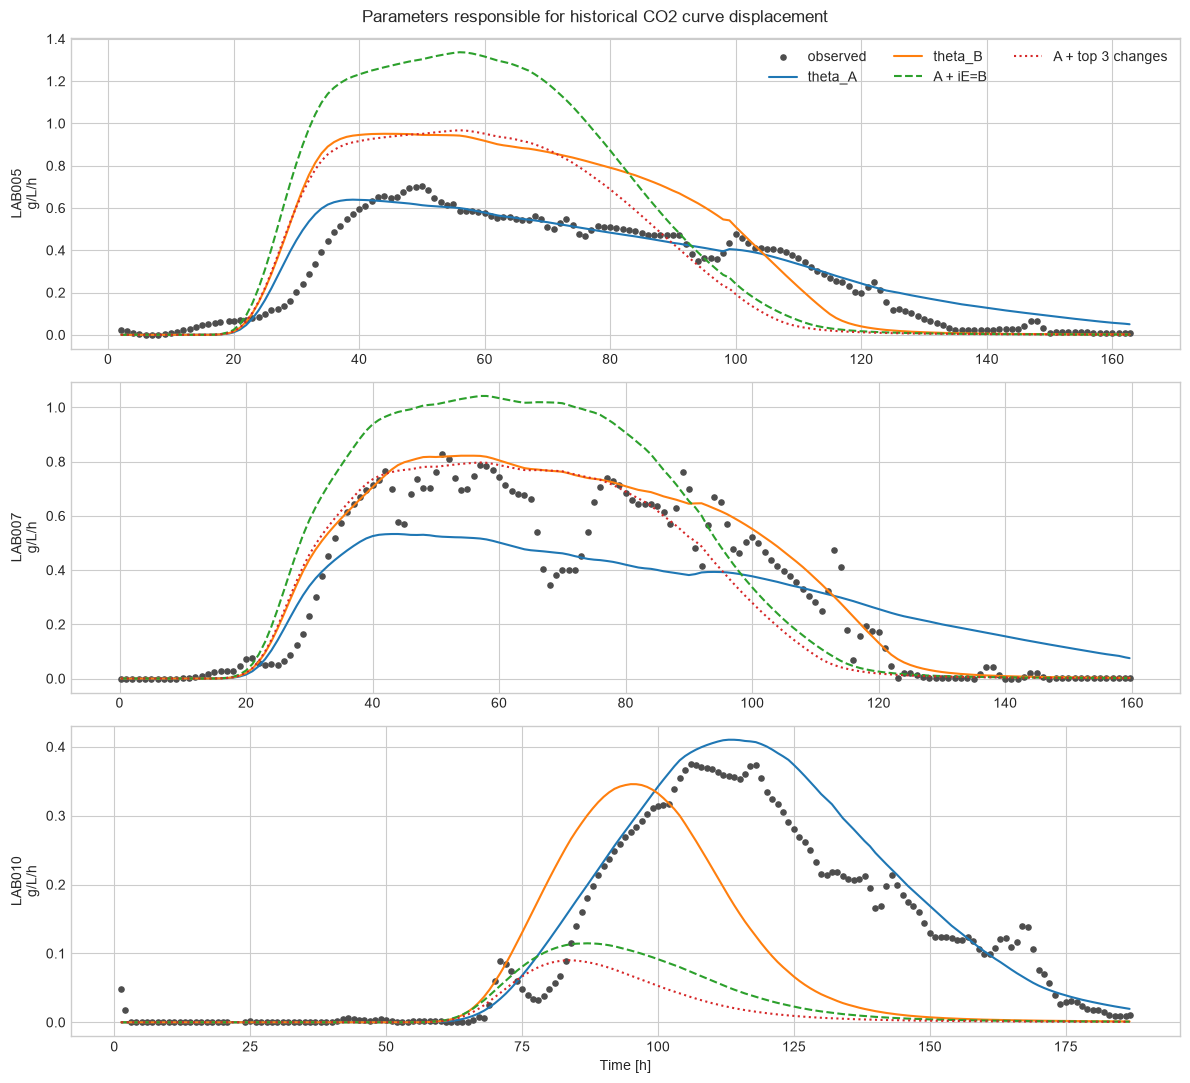

In [23]:
def co2_curve_metrics(bundle):
    rows = []
    pred = bundle["predictions"]
    for batch_name in TRUSTED_HISTORICAL_GAS_BATCHES:
        group = pred[pred["batch"].eq(batch_name)].sort_values("time_h")
        valid = ~group["left_censored"].astype(bool).to_numpy()
        observed = group["observed_g_l_h"].to_numpy(float)
        predicted = group["predicted_g_l_h"].to_numpy(float)
        time = group["time_h"].to_numpy(float)
        peak_index = int(np.nanargmax(predicted))
        rows.append({
            "batch": batch_name,
            "RMSE_g_L_h": float(np.sqrt(np.mean((predicted[valid] - observed[valid])**2))),
            "predicted_peak_g_L_h": float(predicted[peak_index]),
            "predicted_peak_time_h": float(time[peak_index]),
            "predicted_AUC_g_L": float(np.trapz(predicted, time)),
        })
    return pd.DataFrame(rows)

metrics_A_by_batch = co2_curve_metrics(co2_bundle_A)
base_predictions = co2_bundle_A["predictions"][["batch", "time_h", "predicted_g_l_h"]].rename(
    columns={"predicted_g_l_h": "prediction_A"}
)
observed_global_peak = float(co2_bundle_A["predictions"]["observed_g_l_h"].max())

oat_bundles = {}
oat_global_rows = []
oat_batch_rows = []
for name in CORE_PARAMETERS:
    hybrid = dict(theta_A)
    hybrid[name] = theta_B[name]
    bundle = historical_co2_bundle(hybrid, f"A with {name}=B")
    oat_bundles[name] = bundle
    metrics = co2_curve_metrics(bundle)
    comparison = metrics.merge(metrics_A_by_batch, on="batch", suffixes=("_hybrid", "_A"))
    curve = bundle["predictions"][["batch", "time_h", "predicted_g_l_h"]].merge(
        base_predictions, on=["batch", "time_h"]
    )
    curve_rmse = float(np.sqrt(np.mean((curve["predicted_g_l_h"] - curve["prediction_A"])**2)))
    oat_global_rows.append({
        "parameter_changed_A_to_B": name,
        "parameter_change_percent": 100 * (theta_B[name] / theta_A[name] - 1),
        "curve_RMSE_vs_A_g_L_h": curve_rmse,
        "curve_NRMSE_vs_A_observed_peak": curve_rmse / observed_global_peak,
        "delta_global_observed_RMSE_g_L_h": float(metrics["RMSE_g_L_h"].mean() - metrics_A_by_batch["RMSE_g_L_h"].mean()),
        "delta_mean_peak_g_L_h": float(metrics["predicted_peak_g_L_h"].mean() - metrics_A_by_batch["predicted_peak_g_L_h"].mean()),
        "delta_mean_peak_time_h": float(metrics["predicted_peak_time_h"].mean() - metrics_A_by_batch["predicted_peak_time_h"].mean()),
        "delta_mean_AUC_g_L": float(metrics["predicted_AUC_g_L"].mean() - metrics_A_by_batch["predicted_AUC_g_L"].mean()),
    })
    comparison.insert(0, "parameter_changed_A_to_B", name)
    oat_batch_rows.append(comparison)

oat_global = pd.DataFrame(oat_global_rows).sort_values("curve_RMSE_vs_A_g_L_h", ascending=False).reset_index(drop=True)
oat_by_batch = pd.concat(oat_batch_rows, ignore_index=True)
display(oat_global)
display(oat_by_batch.sort_values(["parameter_changed_A_to_B", "batch"]))

top_parameters = oat_global["parameter_changed_A_to_B"].head(3).tolist()
theta_top3 = dict(theta_A)
for name in top_parameters:
    theta_top3[name] = theta_B[name]
bundle_top3 = historical_co2_bundle(theta_top3, "A + top 3 changes")
top_one = top_parameters[0]
representative = ("LAB005", "LAB007", "LAB010")
curves = [
    ("theta_A", co2_bundle_A, "tab:blue", "-"),
    ("theta_B", co2_bundle_B, "tab:orange", "-"),
    (f"A + {top_one}=B", oat_bundles[top_one], "tab:green", "--"),
    ("A + top 3 changes", bundle_top3, "tab:red", ":"),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)
for ax, batch_name in zip(axes, representative):
    observed = co2_bundle_A["predictions"].query("batch == @batch_name").sort_values("time_h")
    ax.scatter(observed["time_h"], observed["observed_g_l_h"], s=14, color="0.3", label="observed")
    for label, bundle, color, linestyle in curves:
        curve = bundle["predictions"].query("batch == @batch_name").sort_values("time_h")
        ax.plot(curve["time_h"], curve["predicted_g_l_h"], color=color, ls=linestyle, label=label)
    ax.set_ylabel(f"{batch_name}\ng/L/h")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time [h]")
fig.suptitle("Parameters responsible for historical CO2 curve displacement")
fig.tight_layout()
plt.show()
print("Top three one-at-a-time CO2 drivers:", top_parameters)

## 20. Combined A → B path

Because the fit used log-parameters, the diagnostic path is geometric:

$$\log\theta(\lambda)=(1-\lambda)\log\theta_A+\lambda\log\theta_B.$$

This is not an optimization. It shows where offline blocks improve and where the
fixed historical gas prediction begins to deteriorate.

,lambda,historical gas CO2,LAB S=G+F,LAB N=YAN,LAB Gly,LAB dissolved CO2
0,0.00,33.234026,1073.330345,1330.815100,248.919438,922.711008
1,0.25,35.604880,1110.841731,1294.275960,232.119422,906.237488
2,0.50,48.935883,1045.984476,1260.809501,197.765501,897.284307
3,0.75,64.311841,896.846326,1230.193627,153.702331,894.884848
4,1.00,73.975361,707.523274,1202.211270,109.375430,897.081167


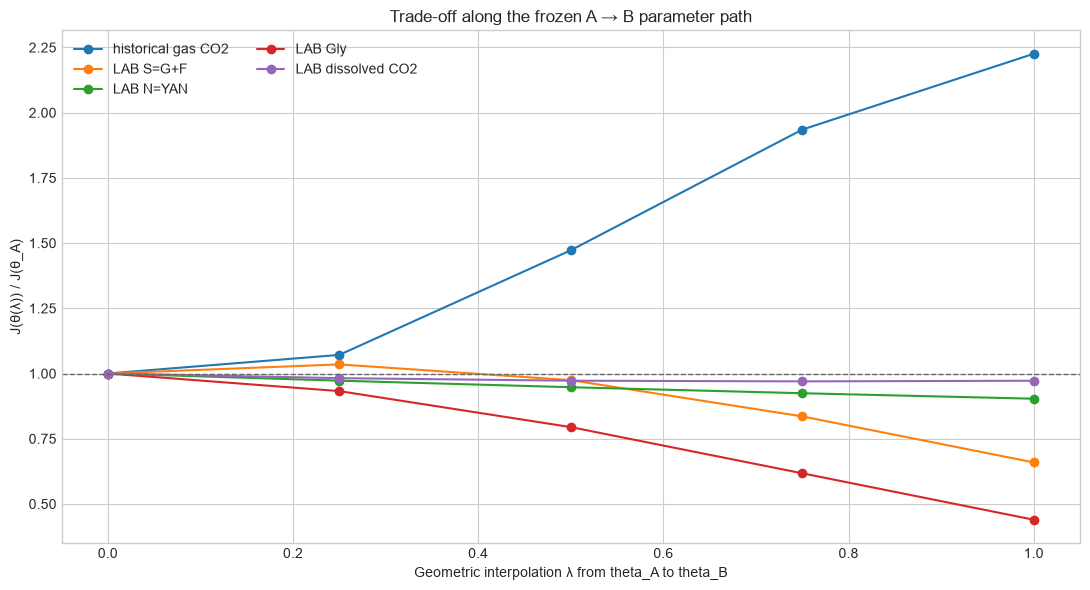

In [24]:
lambdas = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
path_rows = []
path_bundles = {0.0: co2_bundle_A, 1.0: co2_bundle_B}
for lam in lambdas:
    theta_lam = dict(theta_A)
    for name in CORE_PARAMETERS:
        theta_lam[name] = float(np.exp((1-lam)*np.log(theta_A[name]) + lam*np.log(theta_B[name])))
    bundle = path_bundles.get(float(lam))
    if bundle is None:
        bundle = historical_co2_bundle(theta_lam, f"lambda={lam:.2f}")
        path_bundles[float(lam)] = bundle
    offline_blocks = offline_blocks_only(theta_lam)
    row = {"lambda": lam, "historical gas CO2": float(bundle["residual"] @ bundle["residual"])}
    row.update({
        "LAB S=G+F": float(offline_blocks["S=G+F"] @ offline_blocks["S=G+F"]),
        "LAB N=YAN": float(offline_blocks["N=YAN"] @ offline_blocks["N=YAN"]),
        "LAB Gly": float(offline_blocks["Gly"] @ offline_blocks["Gly"]),
        "LAB dissolved CO2": float(offline_blocks["dissolved_CO2"] @ offline_blocks["dissolved_CO2"]),
    })
    path_rows.append(row)
path_tradeoff = pd.DataFrame(path_rows)
display(path_tradeoff)

normalized_path = path_tradeoff.set_index("lambda") / path_tradeoff.set_index("lambda").iloc[0]
fig, ax = plt.subplots(figsize=(11, 6))
for column in normalized_path:
    ax.plot(normalized_path.index, normalized_path[column], marker="o", label=column)
ax.axhline(1.0, color="0.4", ls="--", lw=1)
ax.set_xlabel("Geometric interpolation λ from theta_A to theta_B")
ax.set_ylabel("J(θ(λ)) / J(θ_A)")
ax.set_title("Trade-off along the frozen A → B parameter path")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

## 21. Cross-observable sensitivity and incompatible directions

Central finite differences at `theta_A` quantify the RMS change in each scaled
residual vector per unit log-parameter. A second matrix reports the signed
objective gradient $2\,r^T(\partial r/\partial\log\theta)/n$. Opposite signs mean
that two observables prefer opposite movements locally; magnitude and direction
are normalized within each observable only for visualization.

,observable,parameter,RMS_scaled_residual_sensitivity,mean_objective_gradient,normalized_sensitivity,normalized_signed_gradient
48,LAB Gly,gammaG0,4.894284e+00,3.348825e+01,1.000000e+00,1.000000e+00
3,LAB Gly,mu0,2.098568e+00,1.426329e+01,4.287793e-01,4.259193e-01
13,LAB Gly,betaG0,1.251804e+00,-8.487437e+00,2.557685e-01,-2.534452e-01
38,LAB Gly,iE,1.048993e+00,-7.014766e+00,2.143301e-01,-2.094694e-01
8,LAB Gly,qN,8.215887e-01,-4.817489e+00,1.678670e-01,-1.438561e-01
23,LAB Gly,qEG,4.953778e-01,-3.087672e+00,1.012156e-01,-9.220164e-02
33,LAB Gly,iG,3.678540e-01,2.457430e+00,7.515991e-02,7.338185e-02
18,LAB Gly,betaF0,2.236828e-01,-1.488051e+00,4.570286e-02,-4.443500e-02
28,LAB Gly,qEF,1.568952e-02,9.744072e-02,3.205682e-03,2.909698e-03
53,LAB Gly,gammaF0,4.825320e-04,3.270323e-03,9.859092e-05,9.765582e-05


,parameter,CO2_normalized_gradient,mean_offline_normalized_gradient,opposite_local_direction
0,mu0,-1.000000e+00,0.131961,True
2,betaG0,4.073910e-01,-0.241194,True
3,betaF0,5.949077e-01,-0.140123,True
4,qEG,-9.028427e-01,0.164328,True
5,qEF,-6.838694e-01,0.089282,True
8,Kd0,-2.432230e-06,0.000000,True
10,gammaF0,-9.916284e-14,0.000024,True
1,qN,8.016597e-01,0.275546,False
6,iG,4.790912e-01,0.087226,False
7,iE,6.888067e-01,0.005717,False


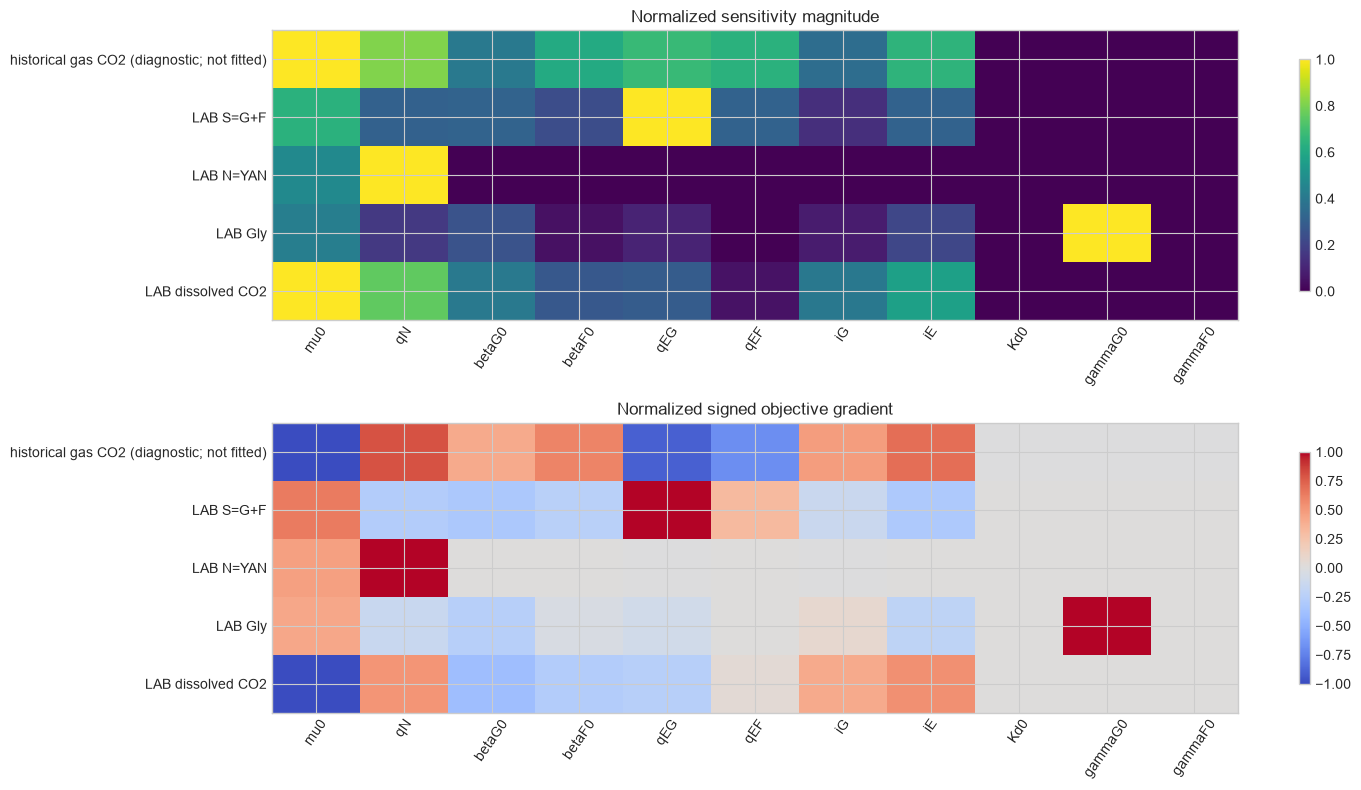

In [25]:
sensitivity_step = 0.03
observable_order = list(diagnostic_arrays_A)
sensitivity_rows = []
for name in CORE_PARAMETERS:
    plus, minus = dict(theta_A), dict(theta_A)
    low, high = base.PARAMETER_BOUNDS[name]
    plus[name] = float(np.clip(theta_A[name] * np.exp(sensitivity_step), low, high))
    minus[name] = float(np.clip(theta_A[name] * np.exp(-sensitivity_step), low, high))
    denominator = np.log(plus[name]) - np.log(minus[name])

    plus_co2 = historical_co2_bundle(plus, f"{name} plus")["residual"]
    minus_co2 = historical_co2_bundle(minus, f"{name} minus")["residual"]
    plus_offline = offline_blocks_only(plus)
    minus_offline = offline_blocks_only(minus)
    arrays_plus = {
        observable_order[0]: plus_co2,
        "LAB S=G+F": plus_offline["S=G+F"],
        "LAB N=YAN": plus_offline["N=YAN"],
        "LAB Gly": plus_offline["Gly"],
        "LAB dissolved CO2": plus_offline["dissolved_CO2"],
    }
    arrays_minus = {
        observable_order[0]: minus_co2,
        "LAB S=G+F": minus_offline["S=G+F"],
        "LAB N=YAN": minus_offline["N=YAN"],
        "LAB Gly": minus_offline["Gly"],
        "LAB dissolved CO2": minus_offline["dissolved_CO2"],
    }
    for observable in observable_order:
        derivative = (arrays_plus[observable] - arrays_minus[observable]) / denominator
        residual_A = diagnostic_arrays_A[observable]
        sensitivity_rows.append({
            "observable": observable, "parameter": name,
            "RMS_scaled_residual_sensitivity": float(np.sqrt(np.mean(derivative**2))),
            "mean_objective_gradient": float(2 * np.mean(residual_A * derivative)),
        })
observable_sensitivity = pd.DataFrame(sensitivity_rows)
observable_sensitivity["normalized_sensitivity"] = observable_sensitivity.groupby("observable")[
    "RMS_scaled_residual_sensitivity"
].transform(lambda x: x / max(float(x.max()), 1e-12))
observable_sensitivity["normalized_signed_gradient"] = observable_sensitivity.groupby("observable")[
    "mean_objective_gradient"
].transform(lambda x: x / max(float(x.abs().max()), 1e-12))
display(observable_sensitivity.sort_values(["observable", "normalized_sensitivity"], ascending=[True, False]))

magnitude_matrix = observable_sensitivity.pivot(index="observable", columns="parameter", values="normalized_sensitivity").loc[observable_order, CORE_PARAMETERS]
gradient_matrix = observable_sensitivity.pivot(index="observable", columns="parameter", values="normalized_signed_gradient").loc[observable_order, CORE_PARAMETERS]
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
im0 = axes[0].imshow(magnitude_matrix, aspect="auto", vmin=0, vmax=1, cmap="viridis")
im1 = axes[1].imshow(gradient_matrix, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
for ax, matrix, title in ((axes[0], magnitude_matrix, "Normalized sensitivity magnitude"),
                          (axes[1], gradient_matrix, "Normalized signed objective gradient")):
    ax.set_xticks(range(len(CORE_PARAMETERS)), CORE_PARAMETERS, rotation=55)
    ax.set_yticks(range(len(observable_order)), observable_order)
    ax.set_title(title)
fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.tight_layout()
plt.show()

co2_gradient = gradient_matrix.iloc[0]
offline_mean_gradient = gradient_matrix.iloc[1:].mean(axis=0)
gradient_conflicts = pd.DataFrame({
    "parameter": CORE_PARAMETERS,
    "CO2_normalized_gradient": co2_gradient.values,
    "mean_offline_normalized_gradient": offline_mean_gradient.values,
})
gradient_conflicts["opposite_local_direction"] = (
    np.sign(gradient_conflicts["CO2_normalized_gradient"])
    != np.sign(gradient_conflicts["mean_offline_normalized_gradient"])
)
display(gradient_conflicts.sort_values("opposite_local_direction", ascending=False))

## 22. State–observable and weighting audit

Compatibility is judged from the implemented state vector, loader mappings, and
gas-transfer code—not from the fact that a variable was previously used. Effective
weights below are coefficients applied to one residual in the model unit. The
historical CO$_2$ row is diagnostic and has zero weight in the biological A/B fit.

In [26]:
compatibility_audit = pd.DataFrame([
    {
        "measurement": "glucose_fructose_g_L", "classification": "REQUIRES OBSERVATION FUNCTION",
        "evidence": "Current states are separate G and F; loader defines S_GF=G+F, but residual_vector has no S state. Hs=G+F is algebraically justified."
    },
    {
        "measurement": "YAN_mg_L", "classification": "DIRECT",
        "evidence": "Existing loader explicitly sets N_kg_m3=YAN_mg_l*1e-3 and N dynamics consume assimilable N; ammonia+PAN disagreement remains an analytical caveat."
    },
    {
        "measurement": "glycerol_g_L", "classification": "DIRECT",
        "evidence": "STATE_COLUMNS maps Gly to glycerol_g_l with identical g/L units."
    },
    {
        "measurement": "CO2_dissolved_actualT_mg_L", "classification": "NOT FULLY COMPATIBLE",
        "evidence": "Gas layer has an internal numerical pool, not an exported measured observable; it fixes C(0)=0 and requires a wrapper plus mg/L→g/L conversion."
    },
])
display(compatibility_audit)

s_obs = dynamic_y15["glucose_fructose_g_L"].to_numpy(float)
s_sigma = np.sqrt(base.sigma_for_state("G", s_obs/2)**2 + base.sigma_for_state("F", s_obs/2)**2)
n_obs = dynamic_y15["YAN_mg_L"].to_numpy(float) * 1e-3
n_sigma = base.sigma_for_state("N", n_obs)
gly_obs = dynamic_y15["glycerol_g_L"].to_numpy(float)
gly_sigma = base.sigma_for_state("Gly", gly_obs)
d_obs = offline.loc[offline["CO2_dissolved_actualT_mg_L"].notna() & offline["time_h_model"].gt(0),
                    "CO2_dissolved_actualT_mg_L"].to_numpy(float) * 1e-3
d_sigma = np.maximum(0.10, 0.10*np.abs(d_obs))
co2_weights = []
for batch_name in TRUSTED_HISTORICAL_GAS_BATCHES:
    group = historical_gas_observations[historical_gas_observations["batch"].eq(batch_name)]
    sigma = max(0.04, 0.10*float(group["co2_rate_g_l_h"].max()))
    co2_weights.append(1/(sigma*np.sqrt(len(group))))

normalization_rows = [
    {"observable": "historical gas CO2 (diagnostic; not fitted)", "original_unit": "g/L/h", "model_unit": "g/L/h",
     "normalization": "max(0.04,0.10*batch peak)*sqrt(n_batch); timing /12 h", "weight_min": min(co2_weights), "weight_max": max(co2_weights), "used_in_B_objective": False},
    {"observable": "LAB S=G+F", "original_unit": "g/L", "model_unit": "g/L",
     "normalization": "sqrt(sigma_G(S/2)^2+sigma_F(S/2)^2)", "weight_min": float((1/s_sigma).min()), "weight_max": float((1/s_sigma).max()), "used_in_B_objective": True},
    {"observable": "LAB N=YAN", "original_unit": "mg/L", "model_unit": "kg/m3",
     "normalization": "max(0.012,0.08*|N|) kg/m3 after *1e-3", "weight_min": float((1/n_sigma).min()), "weight_max": float((1/n_sigma).max()), "used_in_B_objective": True},
    {"observable": "LAB Gly", "original_unit": "g/L", "model_unit": "g/L",
     "normalization": "max(0.35,0.05*|Gly|)", "weight_min": float((1/gly_sigma).min()), "weight_max": float((1/gly_sigma).max()), "used_in_B_objective": True},
    {"observable": "LAB dissolved CO2", "original_unit": "mg/L", "model_unit": "g/L",
     "normalization": "max(0.10,0.10*|C|) g/L after *1e-3", "weight_min": float((1/d_sigma).min()), "weight_max": float((1/d_sigma).max()), "used_in_B_objective": True},
]
weighting_audit = pd.DataFrame(normalization_rows).merge(diagnostic_decomposition, on="observable")
display(weighting_audit)

,measurement,classification,evidence
0,glucose_fructose_g_L,REQUIRES OBSERVATION FUNCTION,Current states are separate G and F; loader de...
1,YAN_mg_L,DIRECT,Existing loader explicitly sets N_kg_m3=YAN_mg...
2,glycerol_g_L,DIRECT,STATE_COLUMNS maps Gly to glycerol_g_l with id...
3,CO2_dissolved_actualT_mg_L,NOT FULLY COMPATIBLE,"Gas layer has an internal numerical pool, not ..."


,observable,original_unit,model_unit,normalization,weight_min,weight_max,used_in_B_objective,n_residuals,J(theta_A),J(theta_B),change_percent
0,historical gas CO2 (diagnostic; not fitted),g/L/h,g/L/h,"max(0.04,0.10*batch peak)*sqrt(n_batch); timin...",0.616591,1.838037,False,1379,33.234026,73.975361,122.589225
1,LAB S=G+F,g/L,g/L,sqrt(sigma_G(S/2)^2+sigma_F(S/2)^2),0.282843,0.282843,True,21,1073.330345,707.523274,-34.081499
2,LAB N=YAN,mg/L,kg/m3,"max(0.012,0.08*|N|) kg/m3 after *1e-3",50.000000,83.333333,True,21,1330.815100,1202.211270,-9.663538
3,LAB Gly,g/L,g/L,"max(0.35,0.05*|Gly|)",2.857143,2.857143,True,21,248.919438,109.375430,-56.059908
4,LAB dissolved CO2,mg/L,g/L,"max(0.10,0.10*|C|) g/L after *1e-3",4.992511,10.000000,True,18,922.711008,897.081167,-2.777667


## Why offline measurements shift the historical CO2 prediction

In [27]:
offline_only_decomp = diagnostic_decomposition[
    ~diagnostic_decomposition["observable"].str.startswith("historical")
].copy()
pressure_row = offline_only_decomp.loc[offline_only_decomp["J(theta_A)"].idxmax()]
gain_table = offline_only_decomp.assign(
    absolute_J_reduction=lambda x: x["J(theta_A)"] - x["J(theta_B)"]
)
gain_row = gain_table.loc[gain_table["absolute_J_reduction"].idxmax()]
top_oat = oat_global.iloc[0]
top_three_text = ", ".join(top_parameters)
co2_path = path_tradeoff["historical gas CO2"]
first_co2_worse = float(path_tradeoff.loc[co2_path > co2_path.iloc[0], "lambda"].min())
co2_change = float(diagnostic_decomposition.loc[
    diagnostic_decomposition["observable"].str.startswith("historical"), "change_percent"
].iloc[0])
questionable = compatibility_audit.loc[
    compatibility_audit["classification"].ne("DIRECT"), "measurement"
].tolist()
opposing = gradient_conflicts.loc[gradient_conflicts["opposite_local_direction"], "parameter"].tolist()

explanation = f"""
1. **Largest offline pressure on A.** `{pressure_row.observable}` has the largest
   initial offline contribution, $J_A={pressure_row['J(theta_A)']:.1f}$. The largest
   realized reduction from A to B is `{gain_row.observable}`
   ($\Delta J={-gain_row.absolute_J_reduction:.1f}$). Thus “largest mismatch” and
   “term most improved by B” are not assumed to be the same.

2. **Parameters moved by that pressure.** The largest A→B changes are visible in
   the frozen parameter table; the cross-observable gradient identifies opposing
   local directions for `{opposing}`. These are precisely shared kinetic directions
   through which offline substrate, nitrogen, glycerol, and the latent dissolved
   pool can alter upstream biomass, sugar, ethanol, and CO₂ production.

3. **Parameters that actually move historical gas CO₂.** The one-at-a-time ranking
   identifies **{top_three_text}** as the three strongest individual curve drivers.
   The leading change, `{top_oat.parameter_changed_A_to_B}`, produces a curve RMSE
   of {top_oat.curve_RMSE_vs_A_g_L_h:.3f} g/L/h relative to the A prediction and
   changes the observed historical RMSE by
   {top_oat.delta_global_observed_RMSE_g_L_h:+.3f} g/L/h. The per-LAB table and
   LAB005/LAB007/LAB010 figure separate amplitude, timing, and AUC effects.

4. **Are weights the explanation?** Not simply an extreme numerical weight inside
   the fitted offline blocks: every fitted block uses an explicit measurement-scale
   normalization and the historical state block has many more residuals. The decisive
   asymmetry is that historical gas CO₂ has **zero weight** in the biological B
   objective. Its fixed observation layer was calibrated conditionally on theta_A,
   so no fitted term prevents theta_B from invalidating those upstream drivers.

5. **Questionable state–observable links.** `{questionable}` are not direct mappings.
   `G+F` is defensible but requires an algebraic observation function. Dissolved CO₂
   is the important weak link: the internal pool is not an exported analytical
   observable, starts at zero, and requires a unit-conversion wrapper. YAN→N and
   glycerol→Gly are direct under the repository's established convention, with the
   noted YAN component caveat.

6. **Does deterioration appear progressively?** Yes. The first sampled path point
   with $J_{{CO2}}>J_{{CO2}}(theta_A)$ is λ={first_co2_worse:.2f}; by theta_B the
   normalized historical-gas diagnostic changes by {co2_change:+.1f}%. The trade-off
   figure shows which offline improvements precede or accompany that loss.

7. **Conflict or bad formulation?** The evidence is primarily a **conditional
   calibration mismatch**, not proof of irreconcilable biology: theta_B improves
   several historical biological-state residuals and new offline residuals, while
   breaking a gas layer held fixed and omitted from the objective. There is also a
   real local trade-off in shared directions and a questionable dissolved-CO₂
   observation mapping. A joint bias-aware gas/offline objective would be needed later
   to decide whether the remaining conflict is biological; this notebook deliberately
   does not perform that new fit.
"""
display(Markdown(explanation))


1. **Largest offline pressure on A.** `LAB N=YAN` has the largest
   initial offline contribution, $J_A=1330.8$. The largest
   realized reduction from A to B is `LAB S=G+F`
   ($\Delta J=-365.8$). Thus “largest mismatch” and
   “term most improved by B” are not assumed to be the same.

2. **Parameters moved by that pressure.** The largest A→B changes are visible in
   the frozen parameter table; the cross-observable gradient identifies opposing
   local directions for `['mu0', 'betaG0', 'betaF0', 'qEG', 'qEF', 'Kd0', 'gammaF0']`. These are precisely shared kinetic directions
   through which offline substrate, nitrogen, glycerol, and the latent dissolved
   pool can alter upstream biomass, sugar, ethanol, and CO₂ production.

3. **Parameters that actually move historical gas CO₂.** The one-at-a-time ranking
   identifies **iE, betaF0, qEF** as the three strongest individual curve drivers.
   The leading change, `iE`, produces a curve RMSE
   of 0.267 g/L/h relative to the A prediction and
   changes the observed historical RMSE by
   +0.227 g/L/h. The per-LAB table and
   LAB005/LAB007/LAB010 figure separate amplitude, timing, and AUC effects.

4. **Are weights the explanation?** Not simply an extreme numerical weight inside
   the fitted offline blocks: every fitted block uses an explicit measurement-scale
   normalization and the historical state block has many more residuals. The decisive
   asymmetry is that historical gas CO₂ has **zero weight** in the biological B
   objective. Its fixed observation layer was calibrated conditionally on theta_A,
   so no fitted term prevents theta_B from invalidating those upstream drivers.

5. **Questionable state–observable links.** `['glucose_fructose_g_L', 'CO2_dissolved_actualT_mg_L']` are not direct mappings.
   `G+F` is defensible but requires an algebraic observation function. Dissolved CO₂
   is the important weak link: the internal pool is not an exported analytical
   observable, starts at zero, and requires a unit-conversion wrapper. YAN→N and
   glycerol→Gly are direct under the repository's established convention, with the
   noted YAN component caveat.

6. **Does deterioration appear progressively?** Yes. The first sampled path point
   with $J_{CO2}>J_{CO2}(theta_A)$ is λ=0.25; by theta_B the
   normalized historical-gas diagnostic changes by +122.6%. The trade-off
   figure shows which offline improvements precede or accompany that loss.

7. **Conflict or bad formulation?** The evidence is primarily a **conditional
   calibration mismatch**, not proof of irreconcilable biology: theta_B improves
   several historical biological-state residuals and new offline residuals, while
   breaking a gas layer held fixed and omitted from the objective. There is also a
   real local trade-off in shared directions and a questionable dissolved-CO₂
   observation mapping. A joint bias-aware gas/offline objective would be needed later
   to decide whether the remaining conflict is biological; this notebook deliberately
   does not perform that new fit.


## 23. Sugar--CO$_2$ balance audit under a possible upstream-microleak hypothesis

This block is diagnostic only. It does not fit parameters, call an optimizer, or
alter either frozen parameter vector, any weight, bound, datum, or model equation.
For each historical LAB, the initial and final fermentable sugar are the first and
last times at which **both measured** glucose and fructose are finite. No endpoint is
filled by interpolation or model prediction. The approximate reference

$$m_{CO_2,stoich}=0.489\,(S_{initial}-S_{final})$$

is the theoretical hexose-to-CO$_2$ stoichiometry, not an exact process yield. Carbon
also enters biomass, glycerol, and other metabolites. Historical `co2_rate_g_l_h` is
the repository's artifact-filtered, smoothed and non-negative recorded signal. Since
its unit is g CO$_2$ L$^{-1}$ h$^{-1}$, trapezoidal integration against `t_h` gives
g CO$_2$ L$^{-1}$. Left-censored values are retained as recorded; no leak correction
is applied. Consequently, `capture_ratio` is a diagnostic ratio, **not** an exact
leak percentage or proof that a deficit was caused by leakage.


In [28]:
STOICH_CO2_G_PER_G_HEXOSE = 0.489
historical_batch_by_name = {batch.batch: batch for batch in historical_batches}

sugar_rows = []
for batch_name, batch in sorted(historical_batch_by_name.items()):
    time_h = np.asarray(batch.time, dtype=float)
    glucose = np.asarray(batch.observations["G"], dtype=float)
    fructose = np.asarray(batch.observations["F"], dtype=float)
    paired = np.isfinite(time_h) & np.isfinite(glucose) & np.isfinite(fructose)
    paired_idx = np.flatnonzero(paired)
    row = {
        "LAB": batch_name, "n_paired_sugar": int(paired.sum()),
        "sugar_t_initial_h": np.nan, "sugar_t_final_h": np.nan,
        "S_initial_g_L": np.nan, "S_final_g_L": np.nan,
        "DeltaS_g_L": np.nan, "CO2_stoich_g_L": np.nan,
        "sugar_note": "Insufficient paired measured G and F endpoints.",
    }
    if len(paired_idx) >= 2:
        first_idx, last_idx = int(paired_idx[0]), int(paired_idx[-1])
        t_initial, t_final = float(time_h[first_idx]), float(time_h[last_idx])
        if t_final > t_initial:
            s_initial = float(glucose[first_idx] + fructose[first_idx])
            s_final = float(glucose[last_idx] + fructose[last_idx])
            delta_s = s_initial - s_final
            row.update({
                "sugar_t_initial_h": t_initial, "sugar_t_final_h": t_final,
                "S_initial_g_L": s_initial, "S_final_g_L": s_final,
                "DeltaS_g_L": delta_s,
                "CO2_stoich_g_L": STOICH_CO2_G_PER_G_HEXOSE * delta_s if delta_s > 0 else np.nan,
                "sugar_note": ("Measured paired G+F endpoints." if delta_s > 0
                               else "Measured endpoints do not show positive net sugar consumption."),
            })
    sugar_rows.append(row)
sugar_balance = pd.DataFrame(sugar_rows)

gas_rows = []
for batch_name in sorted(historical_batch_by_name):
    group = historical_gas_observations[
        historical_gas_observations["batch"].eq(batch_name)
    ].sort_values("t_h")
    signal = group[["t_h", "co2_rate_g_l_h"]].dropna().copy() if not group.empty else pd.DataFrame()
    if not signal.empty:
        signal = signal.groupby("t_h", as_index=False)["co2_rate_g_l_h"].median().sort_values("t_h")
    usable = (not group.empty and group["calibratable"].astype(bool).any()
              and len(signal) >= 2 and float(signal["t_h"].iloc[-1]) > float(signal["t_h"].iloc[0]))
    if usable:
        gas_time = signal["t_h"].to_numpy(float)
        gas_rate = signal["co2_rate_g_l_h"].to_numpy(float)
        integral = float(np.trapz(gas_rate, gas_time))
        peak = float(np.nanmax(gas_rate))
        left_censored_fraction = float(group["left_censored"].astype(bool).mean())
        gas_note = (f"Recorded processed gas integrated on {gas_time[0]:.2f}-{gas_time[-1]:.2f} h; "
                    f"{left_censored_fraction:.1%} of hourly values are left-censored.")
        gas_rows.append({
            "LAB": batch_name, "CO2_measured_integral_g_L": integral,
            "CO2_peak_g_L_h": peak, "gas_t_initial_h": float(gas_time[0]),
            "gas_t_final_h": float(gas_time[-1]), "n_gas_points": int(len(signal)),
            "max_gas_gap_h": float(np.diff(gas_time).max()),
            "left_censored_fraction": left_censored_fraction,
            "sensor_id": int(group["sensor_id"].iloc[0]),
            "acquisition_channel": str(group["acquisition_channel"].iloc[0]),
            "median_setpoint_C": float(group["setpoint_c"].median()),
            "gas_note": gas_note,
        })
    else:
        gas_rows.append({
            "LAB": batch_name, "CO2_measured_integral_g_L": np.nan,
            "CO2_peak_g_L_h": np.nan, "gas_t_initial_h": np.nan,
            "gas_t_final_h": np.nan, "n_gas_points": 0,
            "max_gas_gap_h": np.nan, "left_censored_fraction": np.nan,
            "sensor_id": np.nan, "acquisition_channel": None,
            "median_setpoint_C": np.nan,
            "gas_note": "No homologated usable historical gas signal; no integral or capture ratio reported.",
        })
gas_balance = pd.DataFrame(gas_rows)

historical_balance = sugar_balance.merge(gas_balance, on="LAB", validate="one_to_one")
historical_balance["capture_ratio"] = (
    historical_balance["CO2_measured_integral_g_L"] / historical_balance["CO2_stoich_g_L"]
)
historical_balance["apparent_CO2_deficit_g_L"] = (
    historical_balance["CO2_stoich_g_L"] - historical_balance["CO2_measured_integral_g_L"]
)
historical_balance["observaciones"] = (
    historical_balance["sugar_note"].fillna("") + " " + historical_balance["gas_note"].fillna("")
).str.strip()
capture_table = historical_balance[[
    "LAB", "S_initial_g_L", "S_final_g_L", "DeltaS_g_L", "CO2_stoich_g_L",
    "CO2_measured_integral_g_L", "capture_ratio", "observaciones",
]]
display(capture_table.round(4))

condition_rows = []
for batch_name, batch in sorted(historical_batch_by_name.items()):
    temperature = np.asarray(batch.temperature_c, dtype=float)
    nitrogen_initial = float(batch.initials["N"]) if np.isfinite(batch.initials["N"]) else np.nan
    n_pulses = tuple(batch.pulses.get("N", tuple()))
    condition_rows.append({
        "LAB": batch_name, "medium": str(batch.medium),
        "fermentation_duration_h": float(np.nanmax(batch.time)),
        "temperature_min_C": float(np.nanmin(temperature)),
        "temperature_mean_C": float(np.nanmean(temperature)),
        "temperature_max_C": float(np.nanmax(temperature)),
        "N_initial_mg_L_equivalent": 1000.0 * nitrogen_initial,
        "N_pulse_total_mg_L_equivalent": 1000.0 * sum(float(pulse[1]) for pulse in n_pulses),
    })
historical_conditions = pd.DataFrame(condition_rows)
historical_consistency = historical_balance.merge(historical_conditions, on="LAB", validate="one_to_one")
display(historical_consistency[[
    "LAB", "CO2_peak_g_L_h", "CO2_measured_integral_g_L", "capture_ratio",
    "DeltaS_g_L", "fermentation_duration_h", "temperature_mean_C",
    "N_initial_mg_L_equivalent", "N_pulse_total_mg_L_equivalent", "medium",
    "sensor_id", "acquisition_channel", "left_censored_fraction",
]].round(4))

def audit_correlation(frame, x, y):
    complete = frame[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(complete) < 3 or complete[x].nunique() < 2 or complete[y].nunique() < 2:
        return int(len(complete)), np.nan, np.nan
    return (int(len(complete)), float(complete[x].corr(complete[y])),
            float(complete[x].rank().corr(complete[y].rank())))

association_specs = [
    ("CO2 peak vs capture ratio", "CO2_peak_g_L_h", "capture_ratio"),
    ("CO2 peak vs measured integral", "CO2_peak_g_L_h", "CO2_measured_integral_g_L"),
    ("CO2 peak vs DeltaS", "CO2_peak_g_L_h", "DeltaS_g_L"),
    ("measured integral vs DeltaS", "CO2_measured_integral_g_L", "DeltaS_g_L"),
    ("capture ratio vs mean temperature", "capture_ratio", "temperature_mean_C"),
    ("capture ratio vs initial N", "capture_ratio", "N_initial_mg_L_equivalent"),
    ("capture ratio vs duration", "capture_ratio", "fermentation_duration_h"),
]
correlation_rows = []
for association, x, y in association_specs:
    n_complete, pearson_r, spearman_r = audit_correlation(historical_consistency, x, y)
    correlation_rows.append({"association": association, "n": n_complete,
                             "Pearson_r": pearson_r, "Spearman_r": spearman_r})
consistency_correlations = pd.DataFrame(correlation_rows)
display(consistency_correlations.round(4))

valid_capture = historical_consistency.dropna(subset=["capture_ratio"]).copy()
q1, q3 = valid_capture["capture_ratio"].quantile([0.25, 0.75])
iqr = float(q3 - q1)
outlier_mask = ((valid_capture["capture_ratio"] < q1 - 1.5 * iqr)
                | (valid_capture["capture_ratio"] > q3 + 1.5 * iqr))
capture_outliers_iqr = valid_capture.loc[outlier_mask, "LAB"].tolist()
capture_summary = pd.DataFrame([{
    "n_balances": int(len(valid_capture)),
    "n_capture_ratio_below_1": int(valid_capture["capture_ratio"].lt(1).sum()),
    "capture_ratio_mean": float(valid_capture["capture_ratio"].mean()),
    "capture_ratio_median": float(valid_capture["capture_ratio"].median()),
    "capture_ratio_min": float(valid_capture["capture_ratio"].min()),
    "capture_ratio_max": float(valid_capture["capture_ratio"].max()),
    "capture_ratio_CV": float(valid_capture["capture_ratio"].std(ddof=1) / valid_capture["capture_ratio"].mean()),
    "IQR_outlier_LABs": ", ".join(capture_outliers_iqr) if capture_outliers_iqr else "none",
}])
display(capture_summary.round(4))
sensor_capture_summary = (valid_capture.groupby(["sensor_id", "acquisition_channel"], as_index=False)
                          .agg(n_LAB=("LAB", "size"),
                               capture_ratio_mean=("capture_ratio", "mean"),
                               capture_ratio_min=("capture_ratio", "min"),
                               capture_ratio_max=("capture_ratio", "max")))
display(sensor_capture_summary.round(4))

,LAB,S_initial_g_L,S_final_g_L,DeltaS_g_L,CO2_stoich_g_L,CO2_measured_integral_g_L,capture_ratio,observaciones
0,LAB004,145.85,0.06,145.79,71.2913,45.5047,0.6383,Measured paired G+F endpoints. Recorded proces...
1,LAB005,165.66,0.01,165.65,81.0028,47.1841,0.5825,Measured paired G+F endpoints. Recorded proces...
2,LAB006,157.44,0.17,157.27,76.9050,32.7631,0.4260,Measured paired G+F endpoints. Recorded proces...
3,LAB007,152.07,0.01,152.06,74.3573,51.3132,0.6901,Measured paired G+F endpoints. Recorded proces...
4,LAB008,151.10,0.00,151.10,73.8879,43.6359,0.5906,Measured paired G+F endpoints. Recorded proces...
5,LAB009,152.43,0.02,152.41,74.5285,NaN,NaN,Measured paired G+F endpoints. No homologated ...
6,LAB010,155.54,3.25,152.29,74.4698,21.3990,0.2874,Measured paired G+F endpoints. Recorded proces...
7,LAB011,152.28,0.14,152.14,74.3965,51.9713,0.6986,Measured paired G+F endpoints. Recorded proces...
8,LAB012,154.88,0.09,154.79,75.6923,60.9409,0.8051,Measured paired G+F endpoints. Recorded proces...


,LAB,CO2_peak_g_L_h,CO2_measured_integral_g_L,capture_ratio,DeltaS_g_L,fermentation_duration_h,temperature_mean_C,N_initial_mg_L_equivalent,N_pulse_total_mg_L_equivalent,medium,sensor_id,acquisition_channel,left_censored_fraction
0,LAB004,0.8068,45.5047,0.6383,145.79,163.0,19.2579,230.76,80.0,natural,1.0,F1,0.4012
1,LAB005,0.7060,47.1841,0.5825,165.65,163.0,19.3966,227.30,80.0,natural,2.0,F2,0.2654
2,LAB006,0.4094,32.7631,0.4260,157.27,211.0,17.0127,229.12,80.0,natural,3.0,F3,0.3381
3,LAB007,0.8269,51.3132,0.6901,152.06,160.0,19.2165,239.04,80.0,natural,1.0,F1,0.3727
4,LAB008,0.6773,43.6359,0.5906,151.10,160.0,19.1854,239.22,80.0,natural,2.0,F2,0.2919
5,LAB009,NaN,NaN,NaN,152.41,160.0,19.1098,237.40,80.0,natural,NaN,None,NaN
6,LAB010,0.3747,21.3990,0.2874,152.29,187.0,15.4292,225.70,80.0,natural,1.0,F1,0.5459
7,LAB011,1.2782,51.9713,0.6986,152.14,163.0,18.7885,220.24,80.0,natural,2.0,F2,0.5280
8,LAB012,1.2170,60.9409,0.8051,154.79,163.0,18.3437,222.06,80.0,natural,3.0,F3,0.3913


,association,n,Pearson_r,Spearman_r
0,CO2 peak vs capture ratio,8,-0.4599,-0.8944
1,CO2 peak vs measured integral,8,0.9990,-1.0000
2,CO2 peak vs DeltaS,8,-1.0000,-1.0000
3,measured integral vs DeltaS,8,-0.9286,-1.0000
4,capture ratio vs mean temperature,8,0.9983,0.8240
5,capture ratio vs initial N,8,-0.9996,-0.6000
6,capture ratio vs duration,8,1.0000,0.1240


,n_balances,n_capture_ratio_below_1,capture_ratio_mean,capture_ratio_median,capture_ratio_min,capture_ratio_max,capture_ratio_CV,IQR_outlier_LABs
0,8,8,0.5898,0.6144,0.2874,0.8051,0.2786,LAB010


,sensor_id,acquisition_channel,n_LAB,capture_ratio_mean,capture_ratio_min,capture_ratio_max
0,1.0,F1,3,0.5386,0.2874,0.6901
1,2.0,F2,3,0.6239,0.5825,0.6986
2,3.0,F3,2,0.6156,0.4260,0.8051


### Frozen theta comparison and compact diagnostics

The next evaluation only replays the existing model with frozen `theta_A` and
`theta_B`. Predicted gas rates use the unchanged fixed natural-must observation
layer, including its empirical `matrix_gain`, over each complete chemistry horizon.
`CO2_accumulated_predicted_g_L` and `AUC_dCO2_dt_g_L` are intentionally both shown:
the former is the final cumulative trapezoidal integral and the latter is the AUC of
the same rate, so they must be numerically identical. Predicted substrate consumption
is evaluated at the two measured sugar endpoint times used above. The mapped gas AUC
is not a new independent carbon-balance measurement.


,LAB,fit,CO2_accumulated_predicted_g_L,dCO2_dt_peak_predicted_g_L_h,AUC_dCO2_dt_g_L,substrate_consumption_predicted_g_L,substrate_consumption_observed_g_L,substrate_consumption_error_g_L,substrate_abs_error_g_L
0,LAB004,theta_A,43.5396,0.5808,43.5396,128.9870,145.79,-16.8030,16.8030
1,LAB005,theta_A,51.5695,0.6393,51.5695,143.1755,165.65,-22.4745,22.4745
2,LAB006,theta_A,44.5973,0.4095,44.5973,125.7141,157.27,-31.5559,31.5559
3,LAB007,theta_A,46.3195,0.5331,46.3195,126.4779,152.06,-25.5821,25.5821
4,LAB008,theta_A,46.5007,0.5517,46.5007,125.9539,151.10,-25.1461,25.1461
5,LAB009,theta_A,45.8982,0.6617,45.8982,133.4111,152.41,-18.9989,18.9989
6,LAB010,theta_A,24.6811,0.4102,24.6811,149.2172,152.29,-3.0728,3.0728
7,LAB011,theta_A,24.2224,0.5005,24.2224,145.8745,152.14,-6.2655,6.2655
8,LAB012,theta_A,40.7220,0.6264,40.7220,144.1901,154.79,-10.5999,10.5999
9,LAB004,theta_B,56.6590,0.8713,56.6590,145.4601,145.79,-0.3299,0.3299


,fit,mean_CO2_accumulated_g_L,mean_dCO2_dt_peak_g_L_h,mean_predicted_DeltaS_g_L,substrate_MAE_g_L
0,theta_A,40.8945,0.5459,135.8890,17.8332
1,theta_B,46.6208,0.7356,153.3169,1.1754


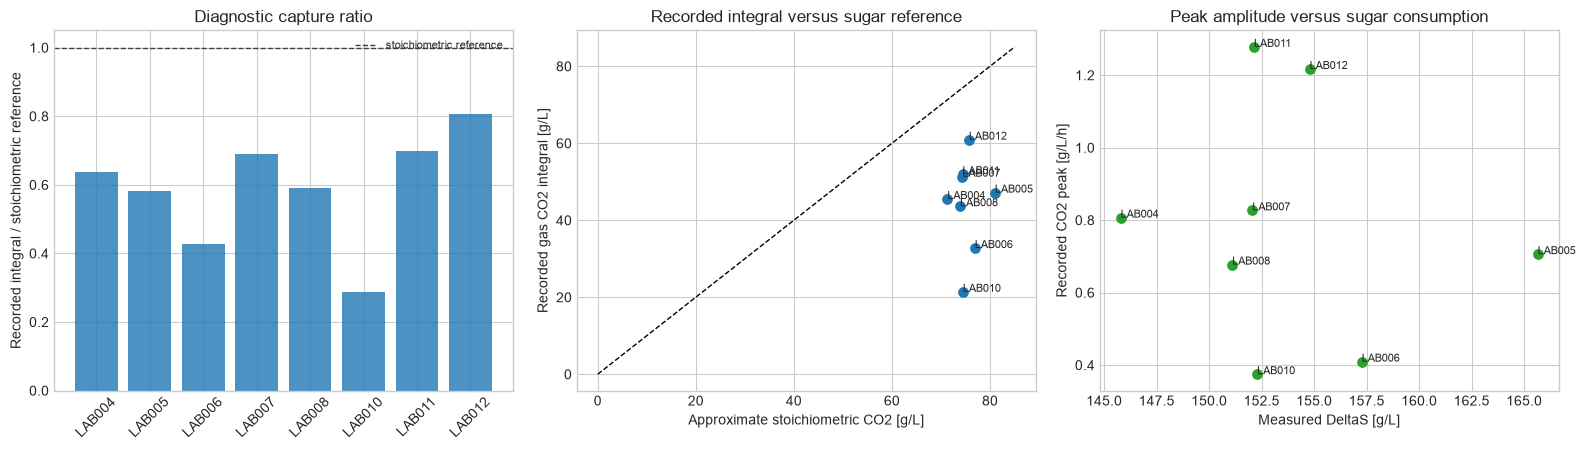

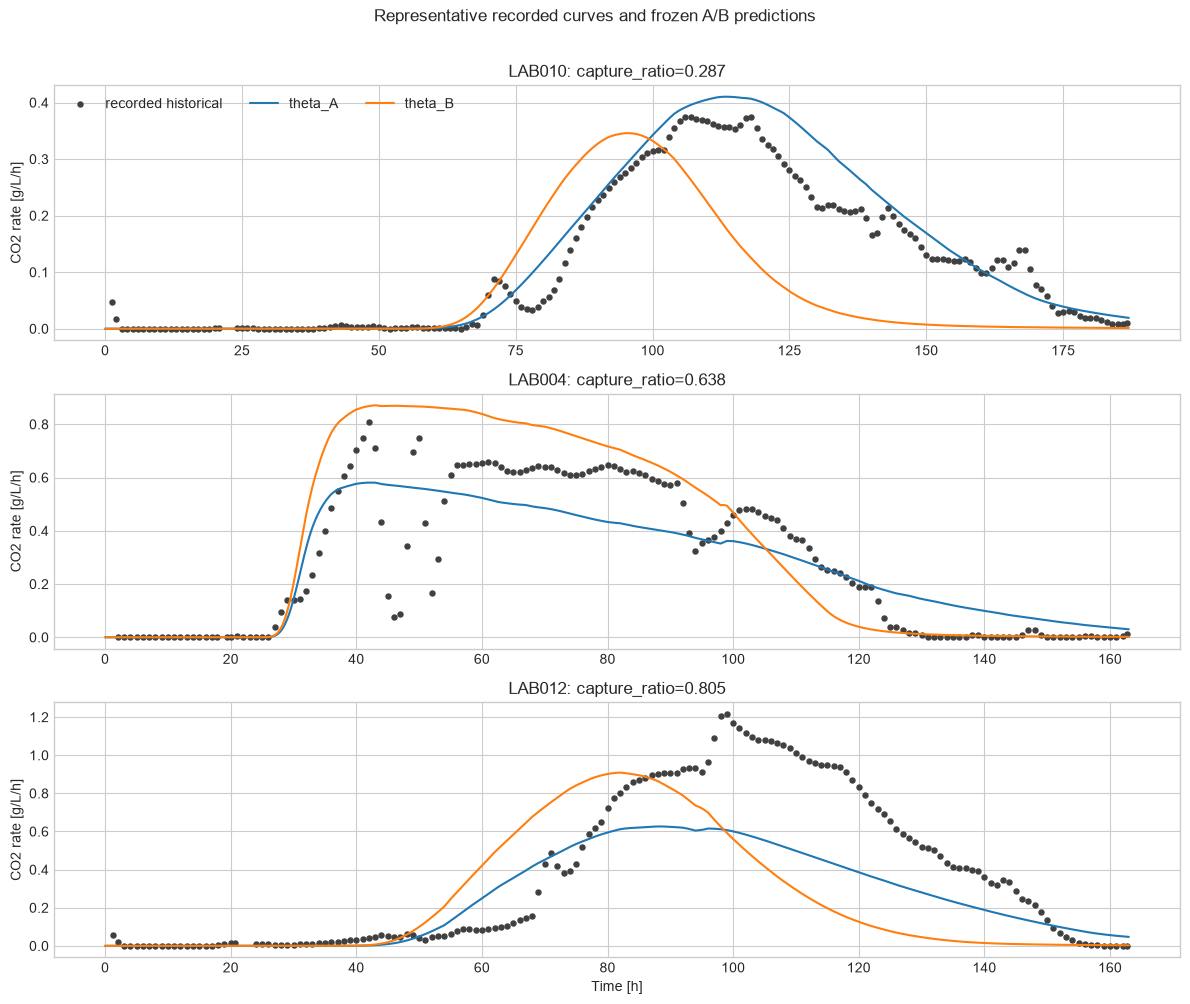

In [29]:
historical_prediction_support = pd.DataFrame([
    {"batch": batch_name, "matrix": "natural", "calibratable": True,
     "t_h": 0.0, "chemistry_last_h": float(batch.time.max())}
    for batch_name, batch in sorted(historical_batch_map.items())
])
historical_full_cache = {}
for fit_name, theta in (("theta_A", theta_A), ("theta_B", theta_B)):
    cache, _ = co2_layer.build_driver_cache(
        historical_batch_map, {"natural": theta}, historical_prediction_support
    )
    historical_full_cache[fit_name] = cache

historical_sugar_predictions = (historical_curves[historical_curves["state"].isin(["G", "F"])]
                                .pivot_table(index=["batch", "fit", "time_h"],
                                             columns="state", values="predicted", aggfunc="first")
                                .dropna(subset=["G", "F"]).reset_index())
historical_sugar_predictions["S_predicted_g_L"] = (
    historical_sugar_predictions["G"] + historical_sugar_predictions["F"]
)
fit_to_curve_label = {"theta_A": "A historical", "theta_B": "B augmented"}

def predicted_sugar_at_measured_time(batch_name, fit_name, time_h):
    if not np.isfinite(time_h):
        return np.nan
    subset = historical_sugar_predictions[
        historical_sugar_predictions["batch"].eq(batch_name)
        & historical_sugar_predictions["fit"].eq(fit_to_curve_label[fit_name])
    ].copy()
    if subset.empty:
        return np.nan
    distance = (subset["time_h"] - float(time_h)).abs()
    if float(distance.min()) > 1e-8:
        return np.nan
    return float(subset.loc[distance.idxmin(), "S_predicted_g_L"])

theta_balance_rows = []
for fit_name in ("theta_A", "theta_B"):
    for batch_name, cache_item in sorted(historical_full_cache[fit_name].items()):
        _, qgas, _, _, _ = dissolved_pool_grid(cache_item)
        predicted_rate = fixed_co2_parameters["matrix_gain"] * qgas
        time_h = cache_item.time_h
        increments = 0.5 * (predicted_rate[1:] + predicted_rate[:-1]) * np.diff(time_h)
        cumulative = np.r_[0.0, np.cumsum(increments)]
        auc = float(np.trapz(predicted_rate, time_h))
        assert np.isclose(float(cumulative[-1]), auc)
        endpoints = sugar_balance[sugar_balance["LAB"].eq(batch_name)].iloc[0]
        predicted_s_initial = predicted_sugar_at_measured_time(
            batch_name, fit_name, endpoints["sugar_t_initial_h"]
        )
        predicted_s_final = predicted_sugar_at_measured_time(
            batch_name, fit_name, endpoints["sugar_t_final_h"]
        )
        predicted_delta_s = (predicted_s_initial - predicted_s_final
                             if np.isfinite(predicted_s_initial) and np.isfinite(predicted_s_final) else np.nan)
        theta_balance_rows.append({
            "LAB": batch_name, "fit": fit_name,
            "CO2_accumulated_predicted_g_L": float(cumulative[-1]),
            "dCO2_dt_peak_predicted_g_L_h": float(np.max(predicted_rate)),
            "AUC_dCO2_dt_g_L": auc,
            "substrate_consumption_predicted_g_L": predicted_delta_s,
            "substrate_consumption_observed_g_L": float(endpoints["DeltaS_g_L"]),
            "substrate_consumption_error_g_L": predicted_delta_s - float(endpoints["DeltaS_g_L"]),
        })
theta_balance_comparison = pd.DataFrame(theta_balance_rows)
theta_balance_comparison["substrate_abs_error_g_L"] = theta_balance_comparison["substrate_consumption_error_g_L"].abs()
display(theta_balance_comparison.round(4))
theta_historical_summary = (theta_balance_comparison.groupby("fit", as_index=False)
                            .agg(mean_CO2_accumulated_g_L=("CO2_accumulated_predicted_g_L", "mean"),
                                 mean_dCO2_dt_peak_g_L_h=("dCO2_dt_peak_predicted_g_L_h", "mean"),
                                 mean_predicted_DeltaS_g_L=("substrate_consumption_predicted_g_L", "mean"),
                                 substrate_MAE_g_L=("substrate_abs_error_g_L", "mean")))
display(theta_historical_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
plot_balance = valid_capture.sort_values("LAB")
axes[0].bar(plot_balance["LAB"], plot_balance["capture_ratio"], color="tab:blue", alpha=0.8)
axes[0].axhline(1.0, color="0.25", ls="--", lw=1, label="stoichiometric reference")
axes[0].set_ylabel("Recorded integral / stoichiometric reference")
axes[0].set_title("Diagnostic capture ratio")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)
axes[1].scatter(plot_balance["CO2_stoich_g_L"], plot_balance["CO2_measured_integral_g_L"], s=45)
limit = 1.05 * max(plot_balance["CO2_stoich_g_L"].max(), plot_balance["CO2_measured_integral_g_L"].max())
axes[1].plot([0, limit], [0, limit], "k--", lw=1)
for _, point in plot_balance.iterrows():
    axes[1].annotate(point["LAB"], (point["CO2_stoich_g_L"], point["CO2_measured_integral_g_L"]), fontsize=8)
axes[1].set_xlabel("Approximate stoichiometric CO2 [g/L]")
axes[1].set_ylabel("Recorded gas CO2 integral [g/L]")
axes[1].set_title("Recorded integral versus sugar reference")
axes[2].scatter(plot_balance["DeltaS_g_L"], plot_balance["CO2_peak_g_L_h"], s=45, color="tab:green")
for _, point in plot_balance.iterrows():
    axes[2].annotate(point["LAB"], (point["DeltaS_g_L"], point["CO2_peak_g_L_h"]), fontsize=8)
axes[2].set_xlabel("Measured DeltaS [g/L]")
axes[2].set_ylabel("Recorded CO2 peak [g/L/h]")
axes[2].set_title("Peak amplitude versus sugar consumption")
fig.tight_layout()
plt.show()

capture_order = plot_balance.sort_values("capture_ratio")
median_capture = float(capture_order["capture_ratio"].median())
representative_labs = list(dict.fromkeys([
    str(capture_order.iloc[0]["LAB"]),
    str(capture_order.loc[(capture_order["capture_ratio"] - median_capture).abs().idxmin(), "LAB"]),
    str(capture_order.iloc[-1]["LAB"]),
]))
fig, axes = plt.subplots(len(representative_labs), 1, figsize=(12, 3.3 * len(representative_labs)), squeeze=False)
for ax, batch_name in zip(axes.ravel(), representative_labs):
    observed = historical_gas_observations[historical_gas_observations["batch"].eq(batch_name)].sort_values("t_h")
    ax.scatter(observed["t_h"], observed["co2_rate_g_l_h"], color="0.25", s=13, label="recorded historical")
    for fit_name, color in (("theta_A", "tab:blue"), ("theta_B", "tab:orange")):
        cache_item = historical_full_cache[fit_name][batch_name]
        _, qgas, _, _, _ = dissolved_pool_grid(cache_item)
        rate = fixed_co2_parameters["matrix_gain"] * qgas
        ax.plot(cache_item.time_h, rate, color=color, label=fit_name)
    ratio = float(plot_balance.loc[plot_balance["LAB"].eq(batch_name), "capture_ratio"].iloc[0])
    ax.set_title(f"{batch_name}: capture_ratio={ratio:.3f}")
    ax.set_ylabel("CO2 rate [g/L/h]")
axes[0, 0].legend(ncol=3)
axes[-1, 0].set_xlabel("Time [h]")
fig.suptitle("Representative recorded curves and frozen A/B predictions", y=1.01)
fig.tight_layout()
plt.show()

### Independent LAB013--LAB015 offline evidence and condition audit

The offline evidence below uses the reported PI composition and final finite
fermentation sample for G+F, YAN and glycerol, plus measured dissolved-CO$_2$ peaks.
Gas-phase CO$_2$ from LAB013--LAB015 remains completely excluded. All historical
and new experiments in this notebook are natural must, so this subset cannot
identify a natural-versus-synthetic medium effect.


In [30]:
def last_finite_value_and_time(frame, value_column, time_column="time_h_model"):
    available = frame[[time_column, value_column]].dropna().sort_values(time_column)
    if available.empty:
        return np.nan, np.nan
    return float(available[value_column].iloc[-1]), float(available[time_column].iloc[-1])

offline_evidence_rows = []
for lab in LABS:
    pi_lab = pi[pi["lab_id"].eq(lab)]
    dyn = dynamic_y15[dynamic_y15["lab_id"].eq(lab)]
    off = offline[offline["lab_id"].eq(lab)]
    s_final, s_final_time = last_finite_value_and_time(dyn, "glucose_fructose_g_L")
    yan_final, yan_final_time = last_finite_value_and_time(dyn, "YAN_mg_L")
    gly_final, gly_final_time = last_finite_value_and_time(dyn, "glycerol_g_L")
    s_initial = float(pi_lab["glucose_fructose_g_L"].iloc[0]) if len(pi_lab) == 1 and pd.notna(pi_lab["glucose_fructose_g_L"].iloc[0]) else np.nan
    yan_initial = float(pi_lab["YAN_mg_L"].iloc[0]) if len(pi_lab) == 1 and pd.notna(pi_lab["YAN_mg_L"].iloc[0]) else np.nan
    gly_initial = float(pi_lab["glycerol_g_L"].iloc[0]) if len(pi_lab) == 1 and pd.notna(pi_lab["glycerol_g_L"].iloc[0]) else np.nan
    dissolved = pd.to_numeric(off["CO2_dissolved_actualT_mg_L"], errors="coerce").dropna() * 1e-3
    temperature = np.asarray(lab_batches[lab].temperature_c, dtype=float)
    offline_evidence_rows.append({
        "LAB": lab, "medium": str(lab_batches[lab].medium),
        "S_initial_PI_g_L": s_initial, "S_final_g_L": s_final,
        "Delta_GF_g_L": s_initial - s_final if np.isfinite(s_initial) and np.isfinite(s_final) else np.nan,
        "S_final_time_h": s_final_time,
        "YAN_initial_PI_mg_L": yan_initial, "YAN_final_mg_L": yan_final,
        "Delta_YAN_mg_L": yan_initial - yan_final if np.isfinite(yan_initial) and np.isfinite(yan_final) else np.nan,
        "YAN_final_time_h": yan_final_time,
        "glycerol_initial_PI_g_L": gly_initial, "glycerol_final_g_L": gly_final,
        "Delta_glycerol_g_L": gly_final - gly_initial if np.isfinite(gly_initial) and np.isfinite(gly_final) else np.nan,
        "glycerol_final_time_h": gly_final_time,
        "dissolved_CO2_peak_g_L": float(dissolved.max()) if not dissolved.empty else np.nan,
        "n_dissolved_CO2": int(len(dissolved)),
        "temperature_mean_C": float(np.nanmean(temperature)),
        "fermentation_duration_h": float(lab_batches[lab].time.max()),
        "new_gas_CO2_used": False,
    })
offline_evidence = pd.DataFrame(offline_evidence_rows)
display(offline_evidence.round(4))
assert not offline_evidence["new_gas_CO2_used"].any()

offline_rmse_summary = (lab_fit_metrics.groupby(["fit", "observable", "unit"], as_index=False)
                        .agg(mean_RMSE=("RMSE", "mean"),
                             mean_bias_pred_minus_obs=("bias_pred_minus_obs", "mean")))
display(offline_rmse_summary.round(4))

condition_comparison = pd.DataFrame([
    {
        "group": "LAB004-LAB012 historical natural", "medium": "natural",
        "n_LAB": int(len(historical_consistency)),
        "S_initial_median_g_L": float(historical_consistency["S_initial_g_L"].median()),
        "S_initial_range_g_L": f"{historical_consistency['S_initial_g_L'].min():.1f}-{historical_consistency['S_initial_g_L'].max():.1f}",
        "N_initial_median_mg_L": float(historical_consistency["N_initial_mg_L_equivalent"].median()),
        "N_initial_range_mg_L": f"{historical_consistency['N_initial_mg_L_equivalent'].min():.1f}-{historical_consistency['N_initial_mg_L_equivalent'].max():.1f}",
        "temperature_mean_range_C": f"{historical_consistency['temperature_mean_C'].min():.1f}-{historical_consistency['temperature_mean_C'].max():.1f}",
        "duration_range_h": f"{historical_consistency['fermentation_duration_h'].min():.1f}-{historical_consistency['fermentation_duration_h'].max():.1f}",
    },
    {
        "group": "LAB013-LAB015 new offline natural", "medium": "natural",
        "n_LAB": int(len(offline_evidence)),
        "S_initial_median_g_L": float(offline_evidence["S_initial_PI_g_L"].median()),
        "S_initial_range_g_L": f"{offline_evidence['S_initial_PI_g_L'].min():.1f}-{offline_evidence['S_initial_PI_g_L'].max():.1f}",
        "N_initial_median_mg_L": float(offline_evidence["YAN_initial_PI_mg_L"].median()),
        "N_initial_range_mg_L": f"{offline_evidence['YAN_initial_PI_mg_L'].min():.1f}-{offline_evidence['YAN_initial_PI_mg_L'].max():.1f}",
        "temperature_mean_range_C": f"{offline_evidence['temperature_mean_C'].min():.1f}-{offline_evidence['temperature_mean_C'].max():.1f}",
        "duration_range_h": f"{offline_evidence['fermentation_duration_h'].min():.1f}-{offline_evidence['fermentation_duration_h'].max():.1f}",
    },
])
display(condition_comparison)

,LAB,medium,S_initial_PI_g_L,S_final_g_L,Delta_GF_g_L,S_final_time_h,YAN_initial_PI_mg_L,YAN_final_mg_L,Delta_YAN_mg_L,YAN_final_time_h,glycerol_initial_PI_g_L,glycerol_final_g_L,Delta_glycerol_g_L,glycerol_final_time_h,dissolved_CO2_peak_g_L,n_dissolved_CO2,temperature_mean_C,fermentation_duration_h,new_gas_CO2_used
0,LAB013,natural,154.65,134.95,19.70,53.6231,249.0,164.0,85.0,53.6231,1.15,2.16,1.01,53.6231,1.9606,7,16.0134,143.5,False
1,LAB014,natural,156.92,130.71,26.21,53.6364,247.0,146.0,101.0,53.6364,1.12,2.39,1.27,53.6364,2.0030,7,16.0333,143.5,False
2,LAB015,natural,154.77,137.72,17.05,53.6764,246.0,168.0,78.0,53.6764,1.12,2.15,1.03,53.6764,1.8445,7,16.0168,143.5,False


,fit,observable,unit,mean_RMSE,mean_bias_pred_minus_obs
0,A,Gly,g/L,1.2041,0.9555
1,A,N=YAN,mg/L,119.1571,-97.5253
2,A,S=G+F,g/L,25.2024,-18.9603
3,B,Gly,g/L,0.7972,0.6044
4,B,N=YAN,mg/L,110.8762,-89.1691
5,B,S=G+F,g/L,20.4257,-14.3400


,group,medium,n_LAB,S_initial_median_g_L,S_initial_range_g_L,N_initial_median_mg_L,N_initial_range_mg_L,temperature_mean_range_C,duration_range_h
0,LAB004-LAB012 historical natural,natural,9,152.43,145.8-165.7,229.12,220.2-239.2,15.4-19.4,160.0-211.0
1,LAB013-LAB015 new offline natural,natural,3,154.77,154.7-156.9,247.00,246.0-249.0,16.0-16.0,143.5-143.5


## Could historical gas leaks explain the CO2 amplitude conflict?

In [31]:
ratio_median = float(valid_capture["capture_ratio"].median())
ratio_min = float(valid_capture["capture_ratio"].min())
ratio_max = float(valid_capture["capture_ratio"].max())
ratio_cv = float(valid_capture["capture_ratio"].std(ddof=1) / valid_capture["capture_ratio"].mean())
n_below = int(valid_capture["capture_ratio"].lt(1.0).sum())
peak_capture = consistency_correlations.loc[
    consistency_correlations["association"].eq("CO2 peak vs capture ratio"), "Spearman_r"
].iloc[0]
peak_integral = consistency_correlations.loc[
    consistency_correlations["association"].eq("CO2 peak vs measured integral"), "Spearman_r"
].iloc[0]
temp_capture = consistency_correlations.loc[
    consistency_correlations["association"].eq("capture ratio vs mean temperature"), "Spearman_r"
].iloc[0]
n_capture = consistency_correlations.loc[
    consistency_correlations["association"].eq("capture ratio vs initial N"), "Spearman_r"
].iloc[0]

theta_summary_indexed = theta_historical_summary.set_index("fit")
auc_change_percent = 100.0 * (
    theta_summary_indexed.loc["theta_B", "mean_CO2_accumulated_g_L"]
    / theta_summary_indexed.loc["theta_A", "mean_CO2_accumulated_g_L"] - 1.0
)
peak_change_percent = 100.0 * (
    theta_summary_indexed.loc["theta_B", "mean_dCO2_dt_peak_g_L_h"]
    / theta_summary_indexed.loc["theta_A", "mean_dCO2_dt_peak_g_L_h"] - 1.0
)
mae_a = float(theta_summary_indexed.loc["theta_A", "substrate_MAE_g_L"])
mae_b = float(theta_summary_indexed.loc["theta_B", "substrate_MAE_g_L"])
substrate_error_wide = theta_balance_comparison.pivot(index="LAB", columns="fit", values="substrate_abs_error_g_L")
n_better_substrate_b = int((substrate_error_wide["theta_B"] < substrate_error_wide["theta_A"]).sum())

offline_delta_s_median = float(offline_evidence["Delta_GF_g_L"].median())
offline_final_time_median = float(offline_evidence["S_final_time_h"].median())
offline_delta_yan_median = float(offline_evidence["Delta_YAN_mg_L"].median())
offline_delta_gly_median = float(offline_evidence["Delta_glycerol_g_L"].median())
offline_dissolved_peak_median = float(offline_evidence["dissolved_CO2_peak_g_L"].median())
outlier_text = ", ".join(capture_outliers_iqr) if capture_outliers_iqr else "none by the 1.5-IQR rule"
historical_temp_min = float(historical_consistency["temperature_mean_C"].min())
historical_temp_max = float(historical_consistency["temperature_mean_C"].max())
historical_n_min = float(historical_consistency["N_initial_mg_L_equivalent"].min())
historical_n_max = float(historical_consistency["N_initial_mg_L_equivalent"].max())
new_temp_min = float(offline_evidence["temperature_mean_C"].min())
new_temp_max = float(offline_evidence["temperature_mean_C"].max())

leak_conclusion = f"""
1. **Do LAB004--LAB012 record less CO2 than the sugar reference?** Among the
   {len(valid_capture)} LABs with both a paired measured sugar balance and usable gas,
   {n_below} have `capture_ratio < 1`. The median is {ratio_median:.3f}, with a range
   of {ratio_min:.3f}--{ratio_max:.3f}. LAB009 has no homologated usable gas signal, so
   no integral or ratio is inferred for it. This comparison uses the approximate
   0.489 g/g theoretical reference; metabolic carbon partitioning, dissolved CO2,
   finite sensor coverage, preprocessing and endpoint error can also lower the ratio.

2. **Is the possible deficit systematic?** The ratio coefficient of variation is
   {ratio_cv:.2f}, and the IQR outlier screen identifies {outlier_text}. Thus the data
   test both a common downward tendency and substantial LAB-to-LAB variation; they do
   not support one exact universal leak fraction. The per-sensor table is descriptive
   only because each channel has few experiments and conditions differ.

3. **Do low peaks coincide with low accumulated balances?** Across usable LABs, the
   Spearman association is {peak_integral:+.3f} for recorded peak versus recorded
   integral and {peak_capture:+.3f} for peak versus `capture_ratio`. Peak amplitude
   therefore cannot by itself diagnose capture loss; the integral and sugar balance
   retain information that a maximum discards.

4. **Does theta_B gain independent consistency?** With the unchanged gas observation
   layer, theta_B changes mean predicted gas AUC by {auc_change_percent:+.1f}% and mean
   predicted peak by {peak_change_percent:+.1f}% relative to theta_A. Against measured
   historical sugar consumption at matched endpoint times, substrate MAE changes from
   {mae_a:.2f} to {mae_b:.2f} g/L, with theta_B closer in {n_better_substrate_b} of
   {len(substrate_error_wide)} LABs. The earlier residual decomposition also shows
   whether B improves new G+F, YAN, glycerol and dissolved-CO2 blocks while worsening
   agreement with recorded gas. This is consistency evidence, not proof that theta_B
   or the fixed gas layer is correct.

5. **Do the new offline data support greater metabolic activity?** By the last offline
   chemistry point at about {offline_final_time_median:.1f} h, LAB013--LAB015 show
   median measured G+F consumption of {offline_delta_s_median:.1f} g/L, YAN depletion
   of {offline_delta_yan_median:.1f} mg/L, glycerol increase of
   {offline_delta_gly_median:.2f} g/L, and a median measured dissolved-CO2 peak of
   {offline_dissolved_peak_median:.3f} g/L. Jointly these are compatible with active
   fermentation that may exceed the activity suggested by some historical gas curves,
   but this is not a final 143.5 h balance, the dissolved-pool mapping remains indirect,
   and new gas is not quantified.

6. **What non-leak differences remain?** Historical mean temperatures span
   {historical_temp_min:.1f}--{historical_temp_max:.1f} C and initial N spans
   {historical_n_min:.1f}--{historical_n_max:.1f} mg/L-equivalent; new LAB means span
   {new_temp_min:.1f}--{new_temp_max:.1f} C. The rank associations of capture ratio
   with mean temperature and initial N are {temp_capture:+.3f} and {n_capture:+.3f},
   respectively, but the sample is small and pulse schedules, initial sugar and duration
   also differ. Every LAB in this notebook is natural must, so no natural-versus-synthetic
   effect can be separated here and none is attributed to leakage.

7. **Can historical gas still be treated as absolute and unbiased?** The independent
   sugar balances, variable capture ratios and censoring/coverage audit are sufficient
   to avoid treating it as an error-free absolute reference. They are not sufficient
   to identify upstream microleaks as the unique cause or to estimate correction factors.

8. **What should precede any correction or refit?** First quantify uncertainty in both
   sugar endpoints and gas integration; close a carbon balance including ethanol,
   glycerol, biomass and dissolved CO2; perform channel-specific known-flow recovery
   and leak/pressure tests upstream of each sensor; and repeat matched conditions with
   independent off-gas measurement. Only then test identifiable batch/sensor capture
   factors in a bias-aware joint model with holdouts. No such factor is introduced here.
"""
display(Markdown(leak_conclusion))


1. **Do LAB004--LAB012 record less CO2 than the sugar reference?** Among the
   8 LABs with both a paired measured sugar balance and usable gas,
   8 have `capture_ratio < 1`. The median is 0.614, with a range
   of 0.287--0.805. LAB009 has no homologated usable gas signal, so
   no integral or ratio is inferred for it. This comparison uses the approximate
   0.489 g/g theoretical reference; metabolic carbon partitioning, dissolved CO2,
   finite sensor coverage, preprocessing and endpoint error can also lower the ratio.

2. **Is the possible deficit systematic?** The ratio coefficient of variation is
   0.28, and the IQR outlier screen identifies LAB010. Thus the data
   test both a common downward tendency and substantial LAB-to-LAB variation; they do
   not support one exact universal leak fraction. The per-sensor table is descriptive
   only because each channel has few experiments and conditions differ.

3. **Do low peaks coincide with low accumulated balances?** Across usable LABs, the
   Spearman association is -1.000 for recorded peak versus recorded
   integral and -0.894 for peak versus `capture_ratio`. Peak amplitude
   therefore cannot by itself diagnose capture loss; the integral and sugar balance
   retain information that a maximum discards.

4. **Does theta_B gain independent consistency?** With the unchanged gas observation
   layer, theta_B changes mean predicted gas AUC by +14.0% and mean
   predicted peak by +34.7% relative to theta_A. Against measured
   historical sugar consumption at matched endpoint times, substrate MAE changes from
   17.83 to 1.18 g/L, with theta_B closer in 8 of
   9 LABs. The earlier residual decomposition also shows
   whether B improves new G+F, YAN, glycerol and dissolved-CO2 blocks while worsening
   agreement with recorded gas. This is consistency evidence, not proof that theta_B
   or the fixed gas layer is correct.

5. **Do the new offline data support greater metabolic activity?** By the last offline
   chemistry point at about 53.6 h, LAB013--LAB015 show
   median measured G+F consumption of 19.7 g/L, YAN depletion
   of 85.0 mg/L, glycerol increase of
   1.03 g/L, and a median measured dissolved-CO2 peak of
   1.961 g/L. Jointly these are compatible with active
   fermentation that may exceed the activity suggested by some historical gas curves,
   but this is not a final 143.5 h balance, the dissolved-pool mapping remains indirect,
   and new gas is not quantified.

6. **What non-leak differences remain?** Historical mean temperatures span
   15.4--19.4 C and initial N spans
   220.2--239.2 mg/L-equivalent; new LAB means span
   16.0--16.0 C. The rank associations of capture ratio
   with mean temperature and initial N are +0.824 and -0.600,
   respectively, but the sample is small and pulse schedules, initial sugar and duration
   also differ. Every LAB in this notebook is natural must, so no natural-versus-synthetic
   effect can be separated here and none is attributed to leakage.

7. **Can historical gas still be treated as absolute and unbiased?** The independent
   sugar balances, variable capture ratios and censoring/coverage audit are sufficient
   to avoid treating it as an error-free absolute reference. They are not sufficient
   to identify upstream microleaks as the unique cause or to estimate correction factors.

8. **What should precede any correction or refit?** First quantify uncertainty in both
   sugar endpoints and gas integration; close a carbon balance including ethanol,
   glycerol, biomass and dissolved CO2; perform channel-specific known-flow recovery
   and leak/pressure tests upstream of each sensor; and repeat matched conditions with
   independent off-gas measurement. Only then test identifiable batch/sensor capture
   factors in a bias-aware joint model with holdouts. No such factor is introduced here.


## Final exclusion and reproducibility checks

This cell verifies the executable objective registry, residual provenance, source
paths, and figure production. The explicit printout is the final guard against any
accidental use of LAB013–LAB015 gas CO$_2$.

In [32]:
assert "gas_phase_CO2" not in LAB_FIT_OBSERVABLES
assert THETA_B_PROVENANCE.startswith("frozen")
assert not objective_registry.query(
    "source == 'LAB013–LAB015' and observable == 'gas_phase_CO2'"
)[["used_in_A", "used_in_B"]].any(axis=None)
assert all(path.is_absolute() for path in requested.values())  # resolved internally
assert all(str(path.relative_to(ROOT)) for path in requested.values())  # provenance is repository-relative
plt.close("all")
assert len(plt.get_fignums()) == 0  # every generated figure was shown before cleanup
assert np.isfinite(objective_residual(theta_B, True)).all()

for lab in LABS:
    used = bool(gas_reference.loc[gas_reference["lab_id"].eq(lab), "used_in_fit"].any())
    assert used is False
    print(f"{lab} gas CO2 used in fit: {used}")
print("Historical gas CO2 used in biological objective A:", False)
print("Historical gas CO2 used in biological objective B:", False)
print("Optimization performed in diagnostic revision: False")
print("Notebook completed with frozen theta_A/theta_B and the declared objective registry.")

LAB013 gas CO2 used in fit: False
LAB014 gas CO2 used in fit: False
LAB015 gas CO2 used in fit: False
Historical gas CO2 used in biological objective A: False
Historical gas CO2 used in biological objective B: False
Optimization performed in diagnostic revision: False
Notebook completed with frozen theta_A/theta_B and the declared objective registry.
